# NDT7 EDA — Myanmar Broadband & Mobile/Cellular (Combined)

Full exploratory analysis of Myanmar NDT7 (M-Lab) data, mirroring the structure of
`notebooks/ookla/myanmar_eda.ipynb` (Fixed Broadband + Mobile/Cellular, same threshold and
plotting sections) so results are directly comparable section-by-section, and mirroring the
prep/EDA split established by `notebooks/ndt7/tigger/cambodia_ndt7_prep.ipynb` /
`cambodia_eda.ipynb`.

Ported from Myanmar's own standalone notebook
(`notebooks/ndt7/mm/mm_clean/ndt7_Myanmar_eda.ipynb`, 17/18 executed code cells with real
output) into this tigger shell — same underlying analysis, restructured to match the
Ookla-style section numbering and the province x quarter CSV input this pipeline uses instead
of live per-row DuckDB queries for the province/regional sections. ISP-level sections (§16-18)
still query the raw parquet directly, same as the source notebook and as Cambodia's tigger
port.

**Input:** `data/exports/ndt7_myanmar_province_quarterly.csv` (Broadband) and
`data/exports/ndt7_mobile_myanmar_province_quarterly.csv` (Mobile) — both produced by
`myanmar_ndt7_prep.ipynb` (tile-binned at Ookla's zoom-16 resolution, `is_reliable` computed
with `total_tests>=100` only (NDT7 drops the `n_tiles>=5` bar that Ookla keeps)
and every other NDT7 tigger prep notebook). This notebook does no raw-data processing for the
province/regional sections — it picks up where the prep notebook leaves off.

Anomaly detection (present in the source notebook's §10) is dropped — excluded from this
project's NDT7/Ookla standardization scope, same as every other tigger notebook.

**Not yet executed in this repo** — Myanmar raw data is not available locally; this notebook
needs a run+verify pass before use, e.g. by whoever has the full local dataset (the source
notebook it's ported from was run there, with real output).


## ISP Overview — Myanmar

Raw NDT7 ISP names from `ndt7/mm/mlab_mm_clean.parquet` (pre-classification, as delivered
by the ISP-matching step) — a diagnostic view of who's actually in the data before it's rolled
up to province-quarter, split by `network_type` and ranked by test volume.

In [1]:
import duckdb

RAW_ISP_PARQUET = '../../../data/ndt7/mm/mlab_mm_clean.parquet'
con = duckdb.connect()
con.execute("SET memory_limit='2GB'")
con.execute("SET threads=2")
isp_counts = con.execute(f"""
    SELECT network_type, isp, COUNT(*) AS n_tests
    FROM read_parquet('{RAW_ISP_PARQUET}')
    GROUP BY network_type, isp
    ORDER BY network_type, n_tests DESC
""").df()
n_unique_isp, n_raw_rows = con.execute(
    f"SELECT COUNT(DISTINCT isp), COUNT(*) FROM read_parquet('{RAW_ISP_PARQUET}')"
).fetchone()
print(f"{n_unique_isp} unique ISP names, {n_raw_rows:,} raw test rows")
isp_counts


91 unique ISP names, 2,115,739 raw test rows


,network_type,isp,n_tests
61,broadband,"Telecom International Myanmar Co., Ltd",256848
40,broadband,"Myanmar Country Co., Ltd.",182419
38,broadband,Myanma Posts and Telecommunications,151899
49,broadband,OOREDOO MYANMAR,116547
1,broadband,5BB Broadband,104973
...,...,...,...
107,hosting,Zenlayer Inc,3
75,hosting,Akamai International B.V.,2
89,hosting,Google LLC,1
90,hosting,HK Broadband Network Ltd.,1


## Province Reference Data

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../../data/reference/myanmar_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 14
Regions: ['Central Dry Zone', 'Eastern Highlands', 'Lower Myanmar / Delta-Coastal', 'Northern / Western Highlands']

province_en                        region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
 Ayeyarwady Lower Myanmar / Delta-Coastal   6184829              177                 165710.4              1
       Chin  Northern / Western Highlands    478801               13                 165710.4              4
    Saigang              Central Dry Zone   5325347               57                 165710.4              3
     Kachin  Northern / Western Highlands   1689441               19                 165710.4              4
      Kayah             Eastern Highlands    286627               24                 165710.4              4
      Kayin Lower Myanmar / Delta-Coastal   1574079               52                 165710.4              3
     Magway              Central Dry Zone   3917055               87                 165710.4      

### Population and GDP by Region — Summary

In [3]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


                               provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                                      
Central Dry Zone                       3        16.57        102.0             165710.0             165710.0
Eastern Highlands                      2         6.11         30.0             165710.0             165710.0
Lower Myanmar / Delta-Coastal          6        23.45        211.0             165710.0             165710.0
Northern / Western Highlands           3         5.36         40.0             165710.0             165710.0


### GDP per Capita vs Population Density — by Region

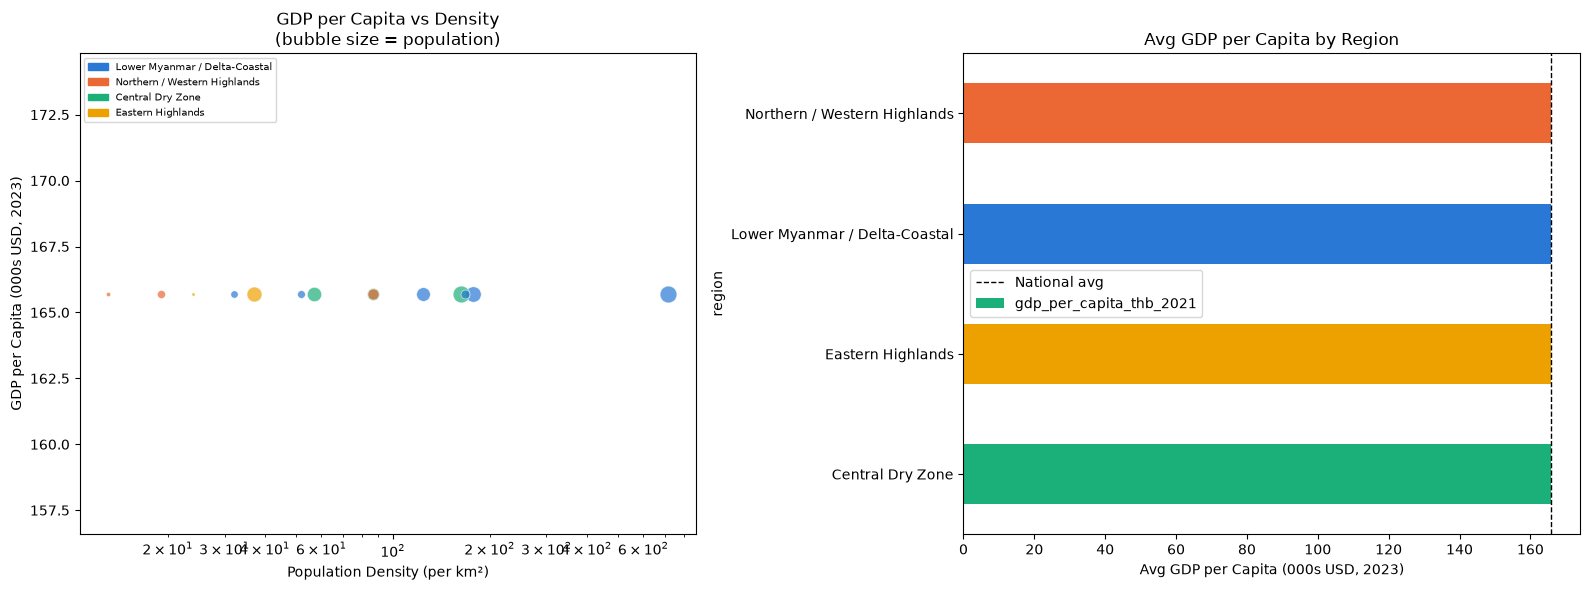

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()
os.makedirs('../../../outputs/ndt7/myanmar', exist_ok=True)
plt.savefig('../../../outputs/ndt7/myanmar/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()


### Internet Tier Distribution — Assumptions Map

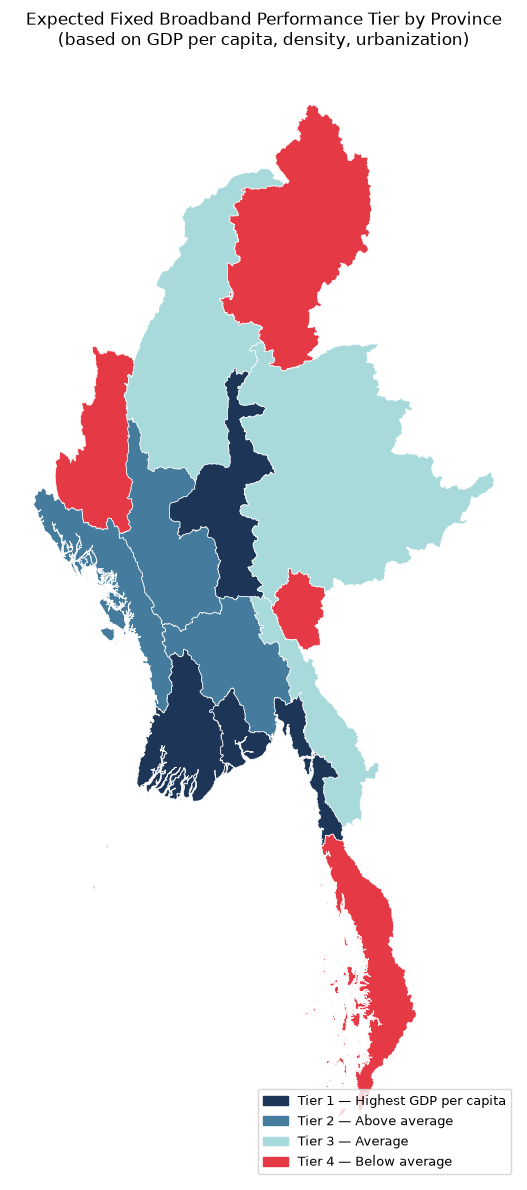

In [5]:
MYANMAR_GEOJSON = '../../../data/geo/myanmar_provinces.geojson'
myanmar_gdf = gpd.read_file(MYANMAR_GEOJSON).to_crs(4326)

tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()
geo_with_tier = myanmar_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig('../../../outputs/ndt7/myanmar/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [6]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP by GDP per Capita ===
province_en                        region  pop_2024  gdp_per_capita_thb_2021  internet_tier
 Ayeyarwady Lower Myanmar / Delta-Coastal   6184829                 165710.4              1
       Chin  Northern / Western Highlands    478801                 165710.4              4
    Saigang              Central Dry Zone   5325347                 165710.4              3
     Kachin  Northern / Western Highlands   1689441                 165710.4              4
      Kayah             Eastern Highlands    286627                 165710.4              4
      Kayin Lower Myanmar / Delta-Coastal   1574079                 165710.4              3
     Magway              Central Dry Zone   3917055                 165710.4              2
   Mandalay              Central Dry Zone   7325965                 165710.4              1
        Mon Lower Myanmar / Delta-Coastal   2054393                 165710.4              1
    Rakhine  Northern / Western Highlands   318880

---
# Part 1 — Broadband

## Full EDA — NDT7 Broadband, Myanmar (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [7]:
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_myanmar_province_quarterly.csv'
GEOJSON  = '../../../data/geo/myanmar_provinces.geojson'
PROV_REF = '../../../data/reference/myanmar_reference.csv'

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

myanmar_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference)")


Master shape: (114, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  12 (of 14 in reference)


In [8]:
# is_reliable already computed upstream (myanmar_ndt7_prep.ipynb, total_tests>=100 only — n_tiles dropped for NDT7, see prep notebook)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")


Reliable province-quarters per label:
label
2023-Q1    7
2023-Q2    3
2023-Q3    8
2023-Q4    6
2024-Q1    8
2024-Q2    7
2024-Q3    6
2024-Q4    7
2025-Q1    7
2025-Q2    6
2025-Q3    5
2025-Q4    6

Overall reliable: 76 / 114 (66.7%)


### 2. Data Quality — Coverage per Province

In [9]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(myanmar_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))


Expected rows (if every province had every quarter): 168 | Actual: 114 | Missing: 54

Provinces with ZERO NDT7 test volume in any quarter (2): ['Rakhine', 'Saigang']

Low-test quarters (< 100 tests) — 37 of 114 province-quarter rows
  name   label  total_tests  n_tiles
 Kayah 2023-Q2          1.0      1.0
 Kayin 2023-Q2          1.0      1.0
 Kayah 2023-Q3          1.0      1.0
  Chin 2024-Q1          1.0      1.0
  Chin 2024-Q2          2.0      1.0
   Mon 2023-Q4          3.0      1.0
   Mon 2024-Q1          4.0      1.0
  Chin 2023-Q1          4.0      1.0
Kachin 2023-Q4          5.0      1.0
  Chin 2025-Q1          5.0      1.0
  Chin 2023-Q4          6.0      1.0
   Mon 2023-Q3          7.0      1.0
   Mon 2023-Q1          9.0      1.0
   Mon 2024-Q2          9.0      1.0
  Chin 2024-Q4          9.0      1.0


In [10]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections below will report "
          "'no reliable data' instead of plotting.")


Filtered to reliable province-quarters: 76 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

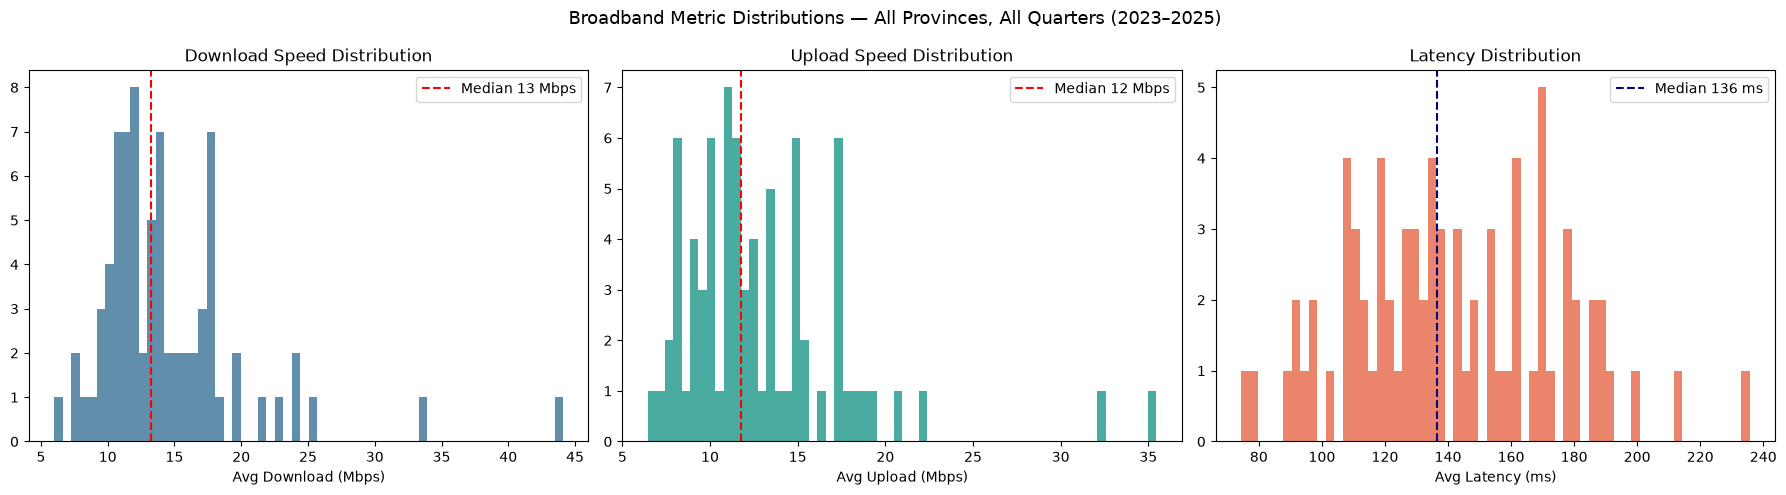

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count       76.00       76.00          76.00        76.00
mean        14.51       13.01         140.87     13380.00
std          5.73        4.90          33.17     29835.16
min          5.99        6.44          74.34       118.00
25%         11.20        9.85         116.93       283.50
50%         13.21       11.76         136.48      1429.00
75%         16.92       14.90         166.93     10174.00
max         44.10       35.46         235.74    193908.00


In [11]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/myanmar/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

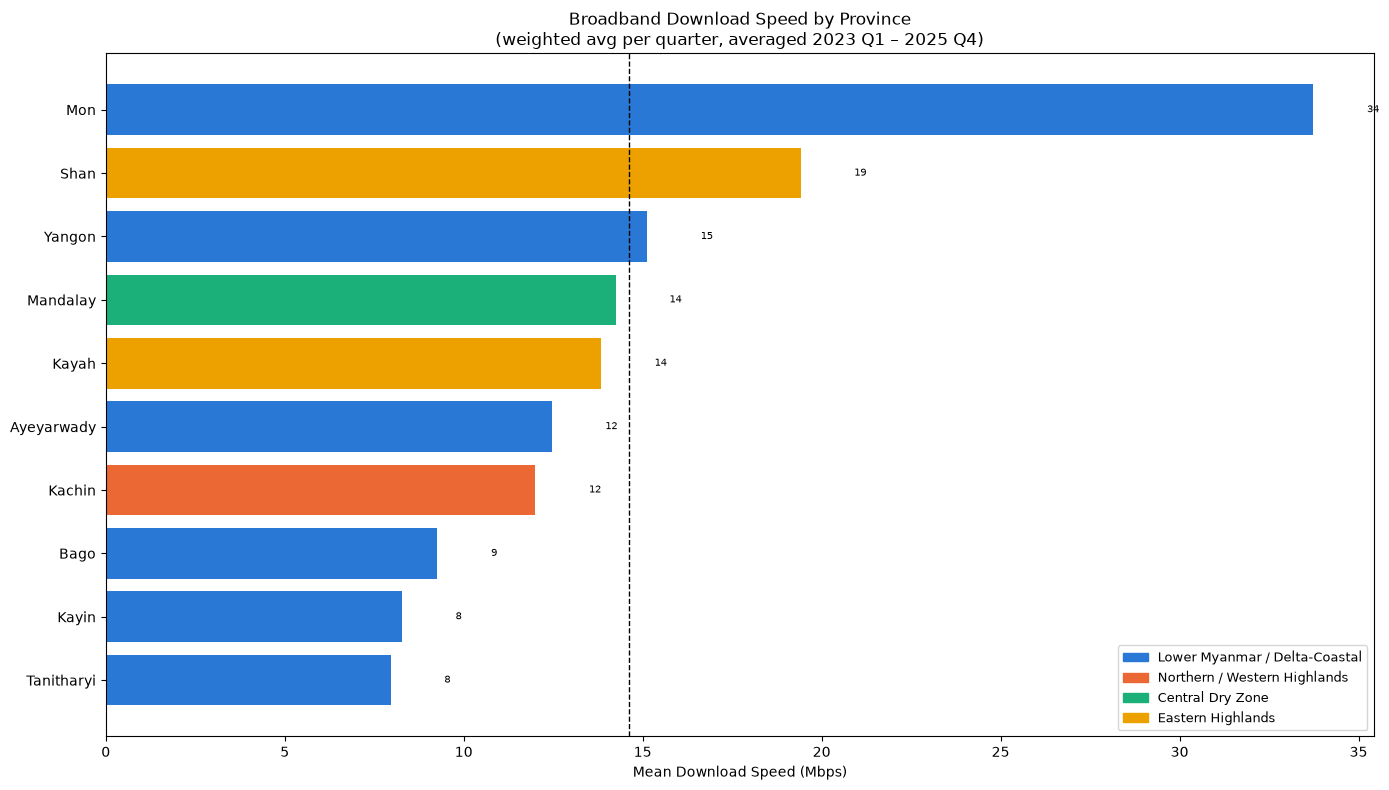

In [12]:
region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Broadband — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

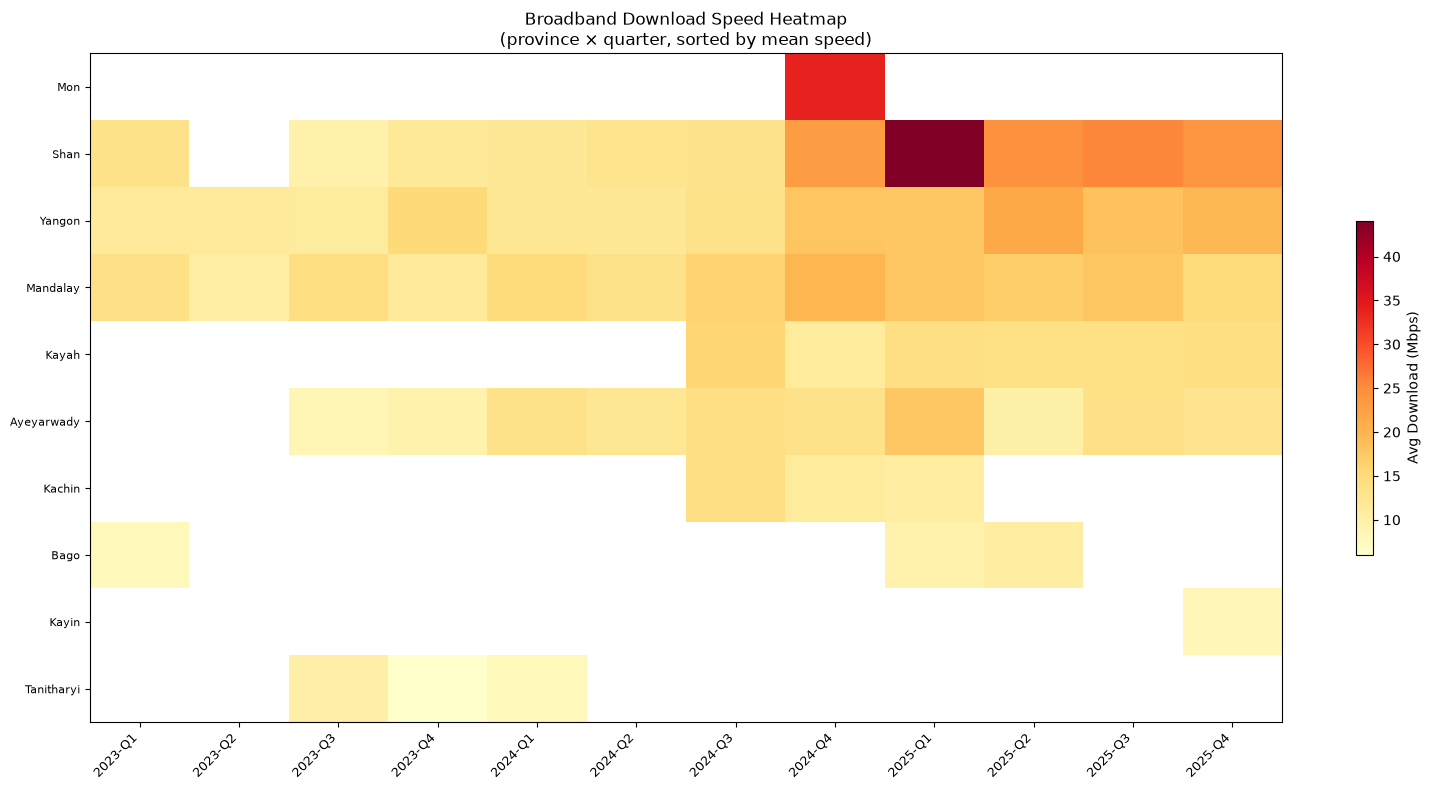

In [13]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()


### 6. Regional Comparison — Download, Upload, Latency

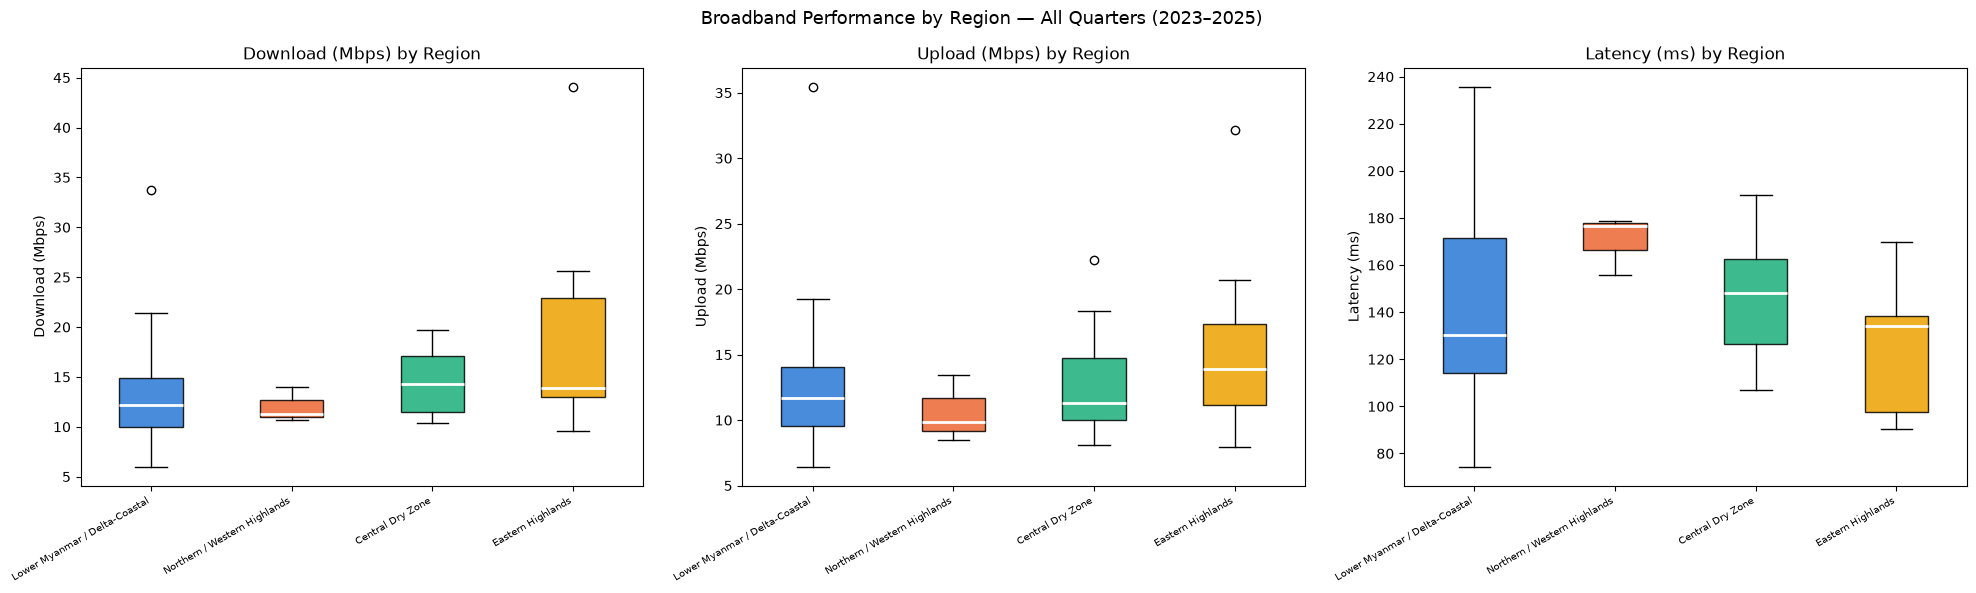

In [14]:
region_order = ['Lower Myanmar / Delta-Coastal', 'Northern / Western Highlands', 'Central Dry Zone', 'Eastern Highlands']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, mlabel, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=7.5)
        ax.set_ylabel(mlabel)
        ax.set_title(f'{mlabel} by Region')
    plt.suptitle('Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

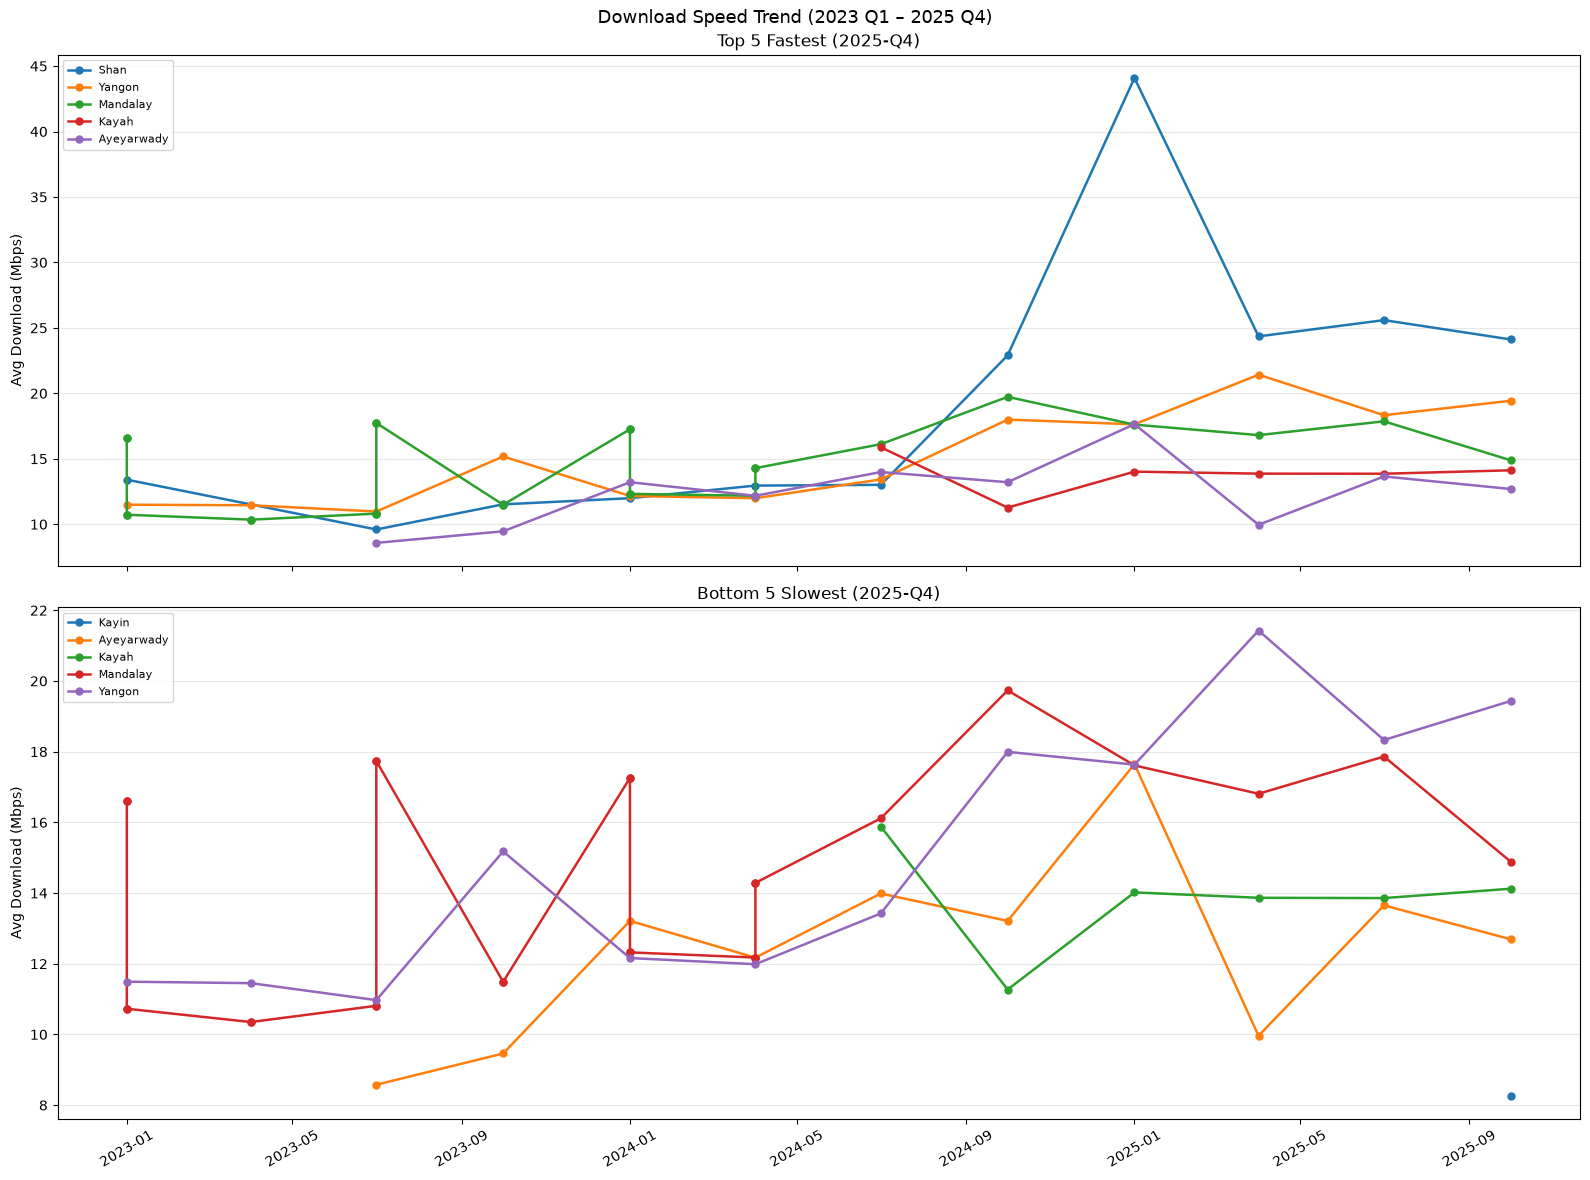

In [15]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

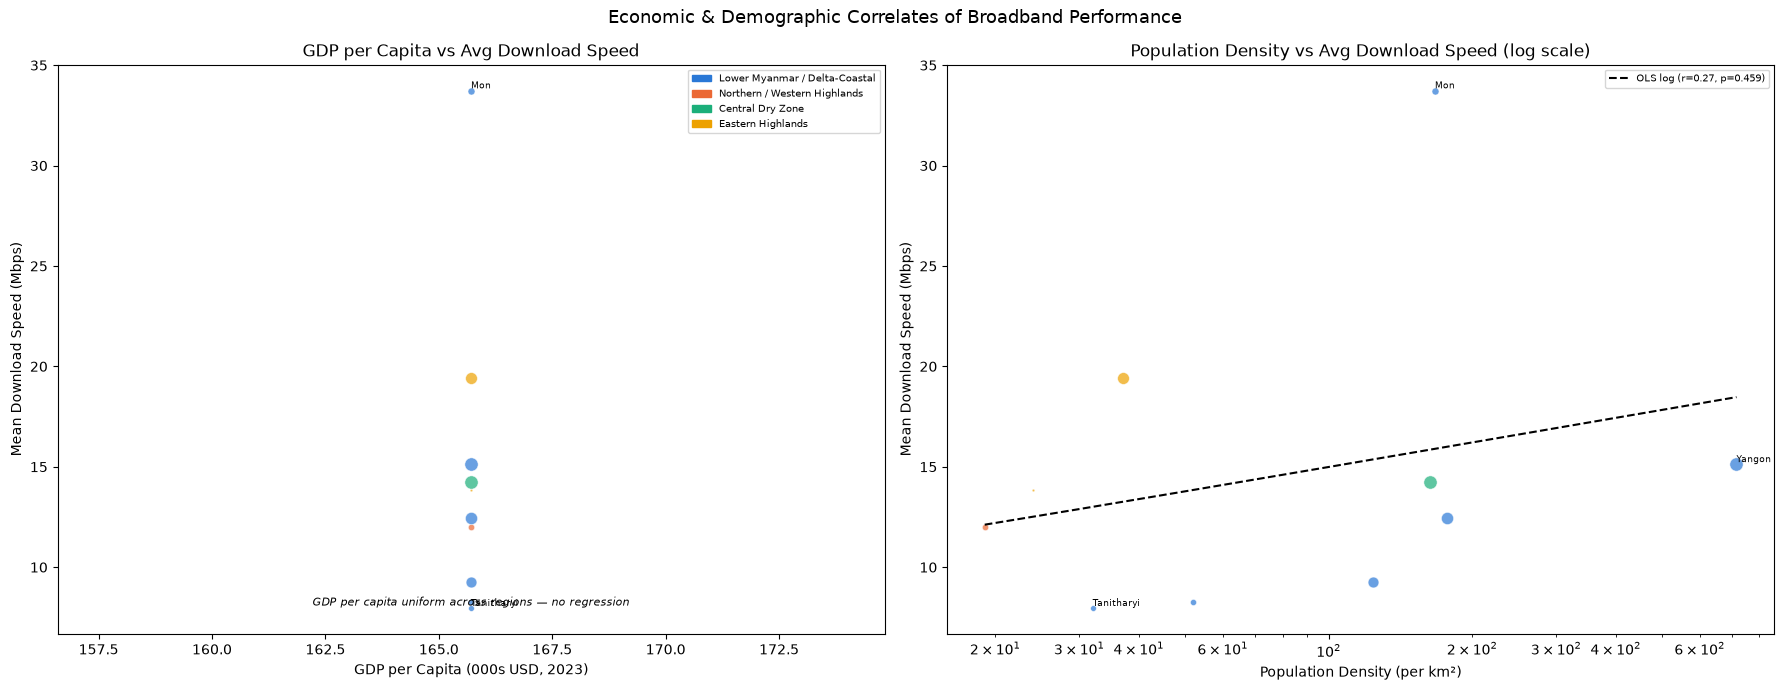

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): 0.265  p=0.4589


In [16]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Broadband — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Broadband Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [17]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R² = {mv_model.rsquared:.3f}  (bivariate GDP-only r² = {r**2:.3f})")
        print(f"Adjusted R² = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                 -0.972
Method:                 Least Squares   F-statistic:                    0.3663
Date:                Thu, 30 Jul 2026   Prob (F-statistic):              0.867
Time:                        13:42:48   Log-Likelihood:                -29.765
No. Observations:                  10   AIC:                             75.53
Df Residuals:                       2   BIC:                             77.95
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### 9. Upload/Download Ratio — Symmetry Check

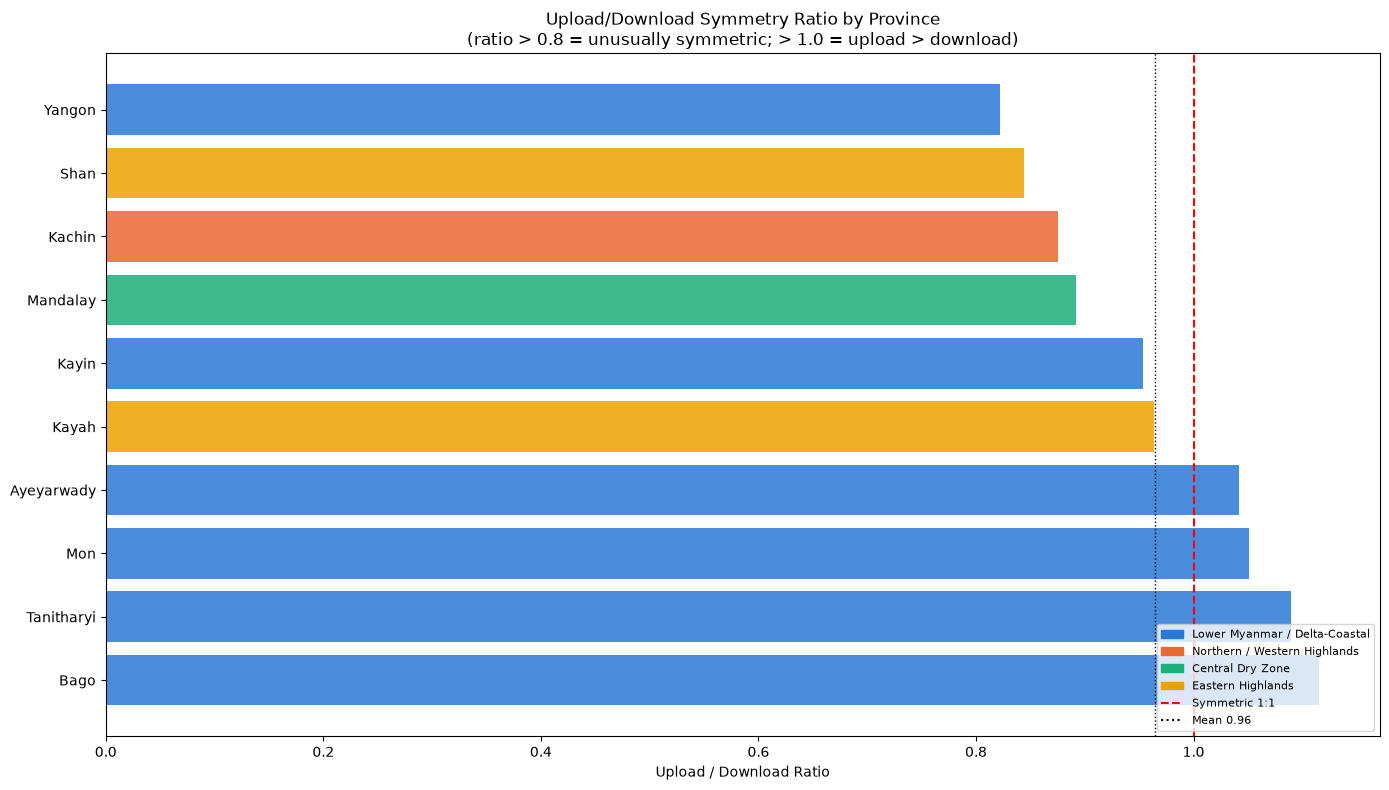

Provinces with UL/DL ratio > 0.8 (10):
      name                        region  ul_dl_ratio
      Bago Lower Myanmar / Delta-Coastal     1.115643
Tanitharyi Lower Myanmar / Delta-Coastal     1.089250
       Mon Lower Myanmar / Delta-Coastal     1.051166
Ayeyarwady Lower Myanmar / Delta-Coastal     1.041534
     Kayah             Eastern Highlands     0.963897
     Kayin Lower Myanmar / Delta-Coastal     0.953138
  Mandalay              Central Dry Zone     0.891626
    Kachin  Northern / Western Highlands     0.875687
      Shan             Eastern Highlands     0.844489
    Yangon Lower Myanmar / Delta-Coastal     0.821972


In [18]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
    print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [19]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Broadband — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())


### 12. Full Province Summary Table

In [20]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))


      name                        region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
       Mon Lower Myanmar / Delta-Coastal              1    33.74    35.46     77.11         1.05      118.00                 165710.4
      Shan             Eastern Highlands              3    19.41    15.66    129.01         0.84      994.82                 165710.4
    Yangon Lower Myanmar / Delta-Coastal              1    15.12    12.33    150.93         0.82    36536.25                 165710.4
  Mandalay              Central Dry Zone              1    14.25    12.59    147.13         0.89    21174.15                 165710.4
     Kayah             Eastern Highlands              4    13.84    13.21    115.88         0.96      637.17                 165710.4
Ayeyarwady Lower Myanmar / Delta-Coastal              1    12.46    12.97    119.48         1.04     1097.80                 165710.4
    Kachin  Northern / Western Highlands              4    12.

### 13. UL/DL Symmetry — Fiber Penetration Evidence

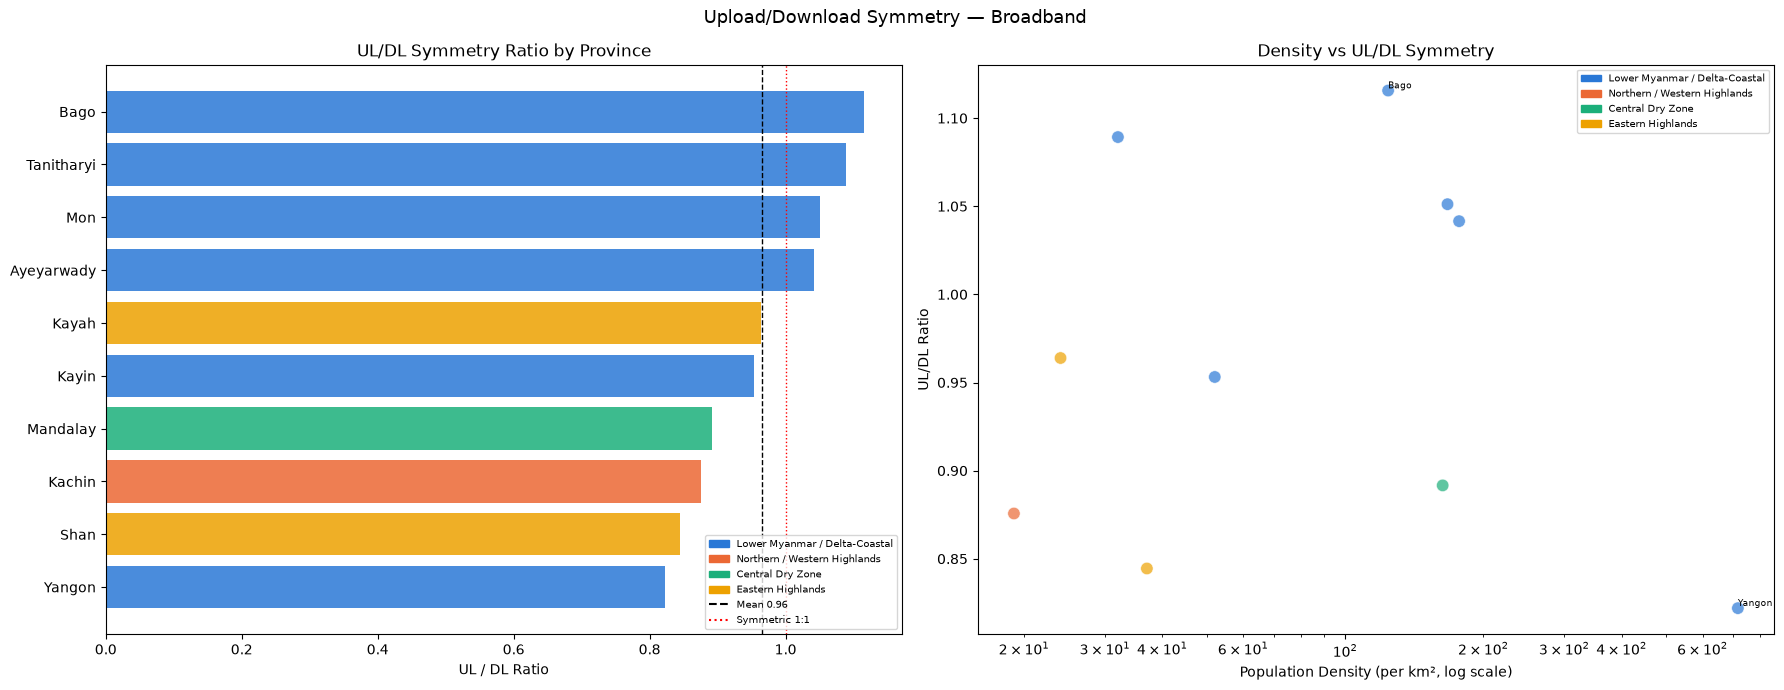

In [21]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Broadband', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

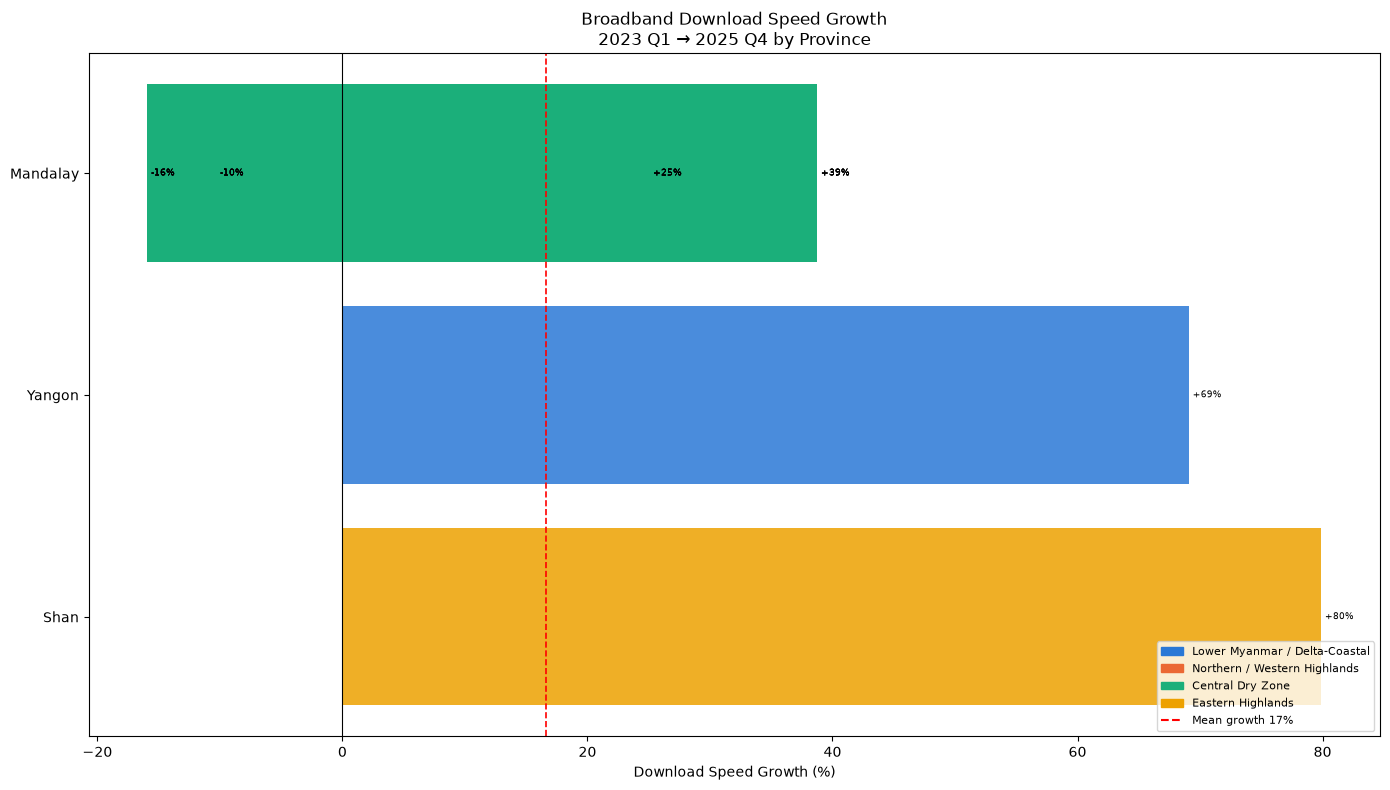

In [22]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 8))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/myanmar/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()


### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 → Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted.

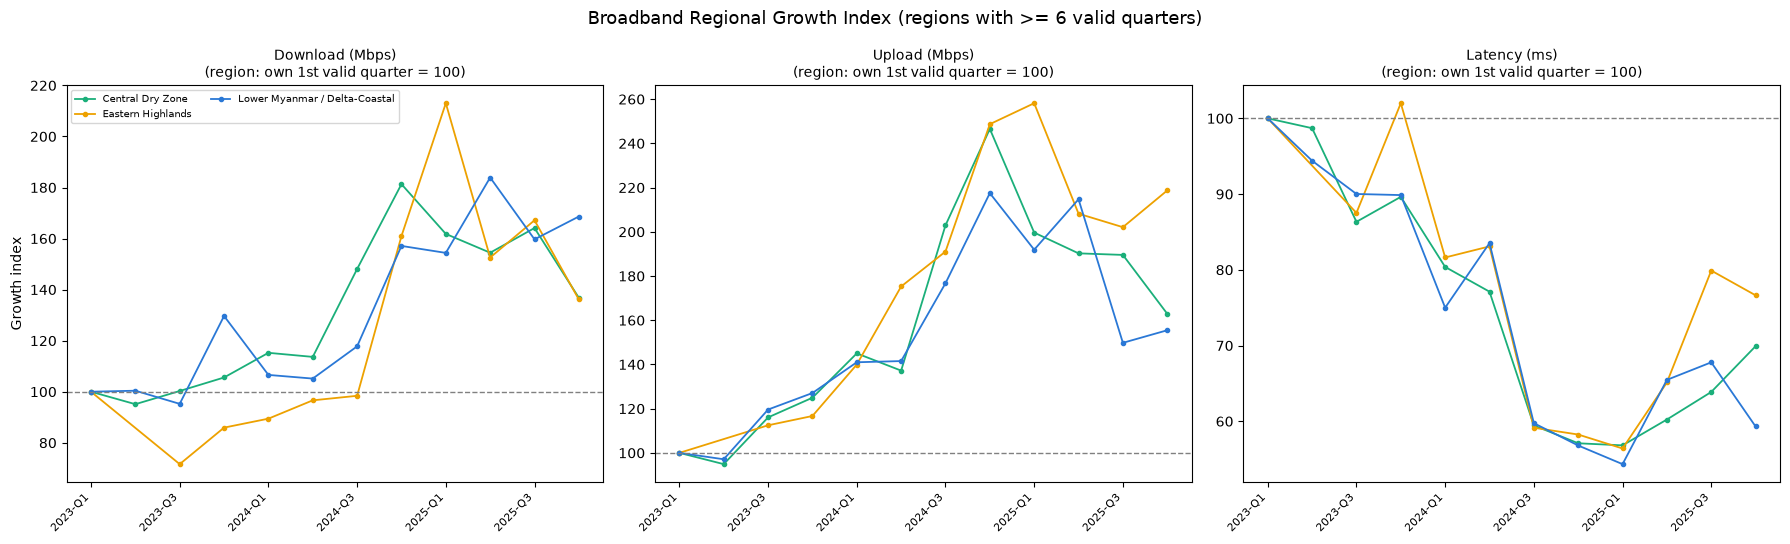

In [23]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, mlabel) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{mlabel}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Broadband Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based expectation. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly.

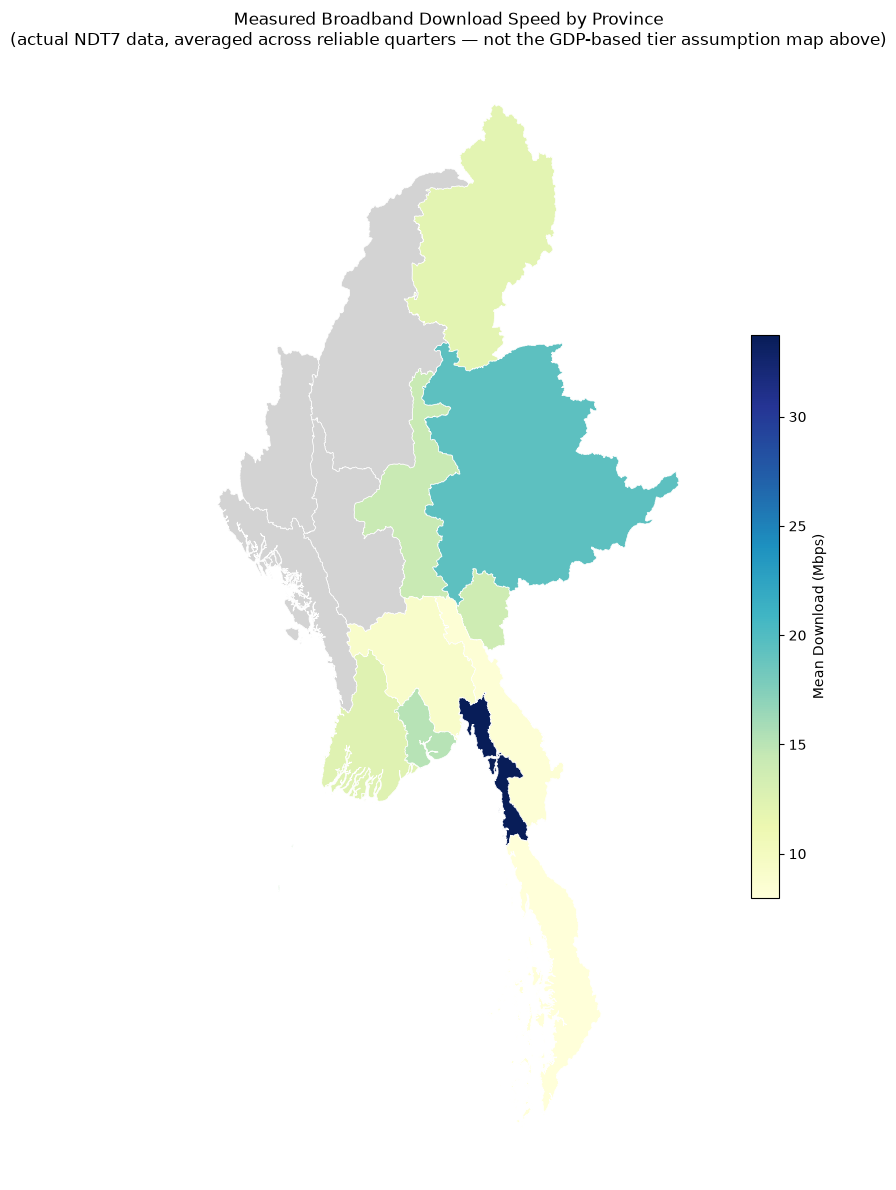

In [24]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = myanmar_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Broadband Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Population (Broadband)
★ = capital (**Nay Pyi Taw**) · 5 cities by population (source: Myanmar 2014 census, Dept. of Population)
— kept as a real population-ranked list (ported from the source NDT7 notebook's own curated
`TOP_CITIES`), unlike Cambodia's tigger port which had to fall back to a test-volume proxy for
lack of a population reference file.

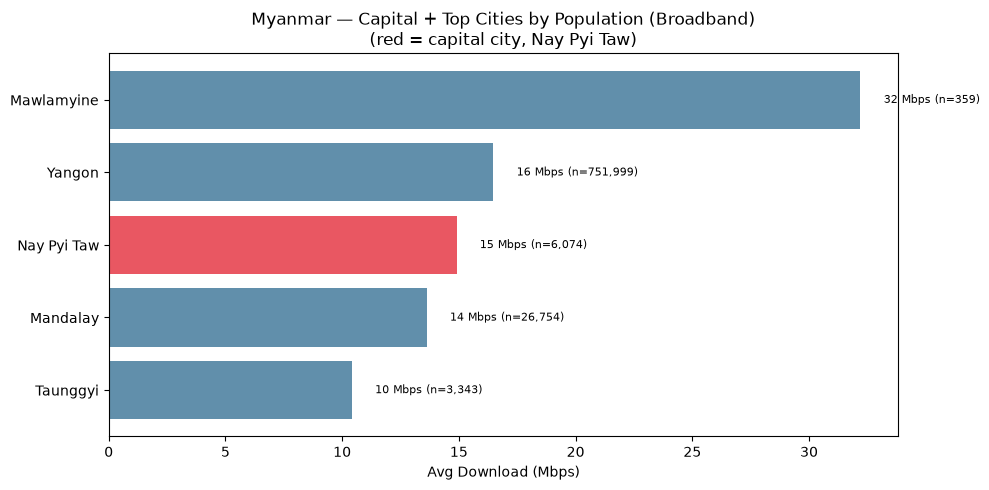

              pop~  n_user  avg_d_mbps  avg_u_mbps  avg_lat_ms
city                                                          
Taunggyi      381k    3343        10.4         9.6       147.6
Mandalay     1.22M   26754        13.6        14.1       112.0
Nay Pyi Taw  1.16M    6074        14.9        13.4       152.2
Yangon       5.21M  751999        16.5        14.3       128.9
Mawlamyine    491k     359        32.2        25.4        96.8


In [25]:
import duckdb

TOP_CITIES = [('Yangon', '5.21M'), ('Mandalay', '1.22M'), ('Nay Pyi Taw', '1.16M'), ('Mawlamyine', '491k'), ('Taunggyi', '381k')]
CAPITAL = 'Nay Pyi Taw'
CITY_LIST = [c for c, _ in TOP_CITIES]
POP = dict(TOP_CITIES)

_con = duckdb.connect()
inlist = ",".join("'" + c.replace("'", "''") + "'" for c in CITY_LIST)
_top_cities = _con.execute(f"""
    SELECT city,
           COUNT(*) AS n_user,
           AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps,
           AVG(mean_throughput_mbps) FILTER (WHERE type='upload')   AS avg_u_mbps,
           AVG(CASE WHEN min_rtt < 2000 THEN min_rtt END) AS avg_lat_ms
    FROM read_parquet('../../../data/ndt7/mm/mlab_mm_clean.parquet')
    WHERE network_type = 'broadband' AND city IN ({inlist})
    GROUP BY city
""").df().set_index('city').reindex(CITY_LIST)

if _top_cities['n_user'].isna().all():
    print("No Broadband city-level data available for the curated city list — skipping city focus.")
else:
    _top_cities.insert(0, 'pop~', [POP[c] for c in CITY_LIST])
    _top_cities['is_capital'] = [c == CAPITAL for c in CITY_LIST]
    _top_cities = _top_cities.sort_values('avg_d_mbps', ascending=True, na_position='first')
    _colors = ['#e63946' if c else '#457b9d' for c in _top_cities['is_capital']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(_top_cities.index, _top_cities['avg_d_mbps'].fillna(0), color=_colors, alpha=0.85)
    for bar, (_, row) in zip(bars, _top_cities.iterrows()):
        label_txt = f"{row['avg_d_mbps']:.0f} Mbps (n={int(row['n_user']):,})" if pd.notna(row['avg_d_mbps']) else "no data"
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, label_txt, va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Myanmar — Capital + Top Cities by Population (Broadband)\n(red = capital city, Nay Pyi Taw)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/23_city_focus.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(_top_cities[['pop~','n_user','avg_d_mbps','avg_u_mbps','avg_lat_ms']].round(1).to_string())


### 17. Per-ISP Ranking — Top ISPs by Test Volume (Broadband)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume.

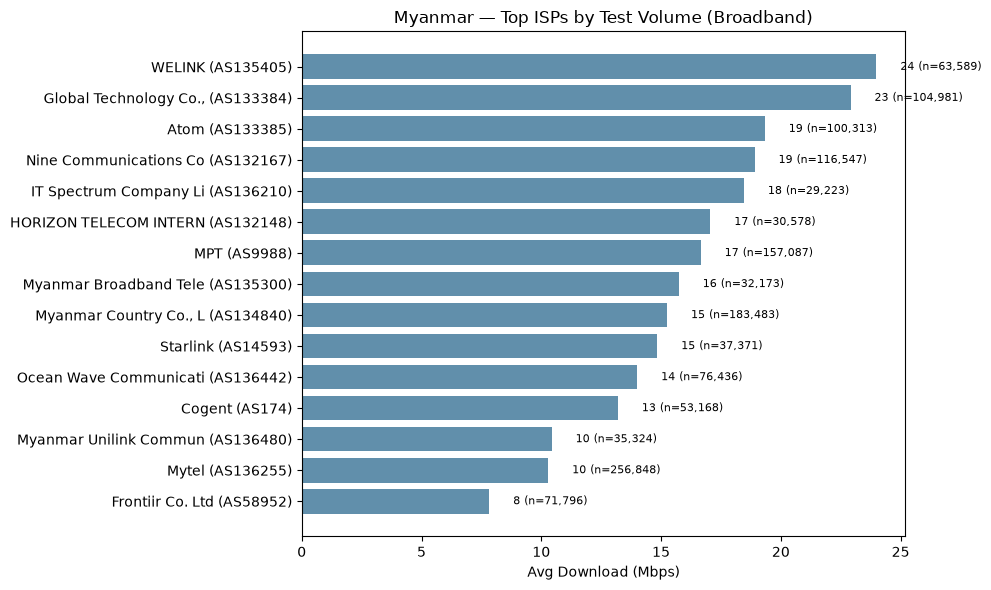

In [26]:
_isp_tbl = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เท่านั้น (HANDOFF ข้อ 1): ip-api คืนชื่อองค์กรลูกค้าสำหรับ leased line
    -- เช่น AS4750 มีชื่อ isp ถึง 420 ชื่อ และชื่อเดียวกันก็กินหลาย ASN (TRUE INTERNET = 9 ASN)
    -- operator/as_name ใช้เป็นป้ายแสดงผลเท่านั้น
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n,
               AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps
        FROM read_parquet('../../../data/ndt7/mm/mlab_mm_clean.parquet')
        WHERE network_type = 'broadband'
        GROUP BY 1
    )
    -- ต่อรหัส ASN ท้ายป้าย: 1 แบรนด์มีได้หลาย ASN (ไทย True=2, AIS=3, NT=3, 3BB=2)
    -- ถ้าป้ายซ้ำ แกน categorical ของ matplotlib จะยุบแท่งทับกัน
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown ASN)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n, avg_d_mbps
    FROM g
    WHERE n >= 100
    ORDER BY n DESC
    LIMIT 15
""").df()

if _isp_tbl.empty:
    print("No ISP meets the n>=100 test threshold for Broadband — skipping per-ISP ranking.")
else:
    _isp_tbl = _isp_tbl.sort_values('avg_d_mbps', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(_isp_tbl))))
    ax.barh(_isp_tbl['isp'].str.slice(0, 40), _isp_tbl['avg_d_mbps'], color='#457b9d', alpha=0.85)
    for yi, (_, row) in enumerate(_isp_tbl.iterrows()):
        ax.text(row['avg_d_mbps'] + 1, yi, f"{row['avg_d_mbps']:.0f} (n={row['n']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Myanmar — Top ISPs by Test Volume (Broadband)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/24_per_isp.png', dpi=150, bbox_inches='tight')
    plt.show()


### 18. Market Share / HHI — ISP Concentration (Broadband)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated.

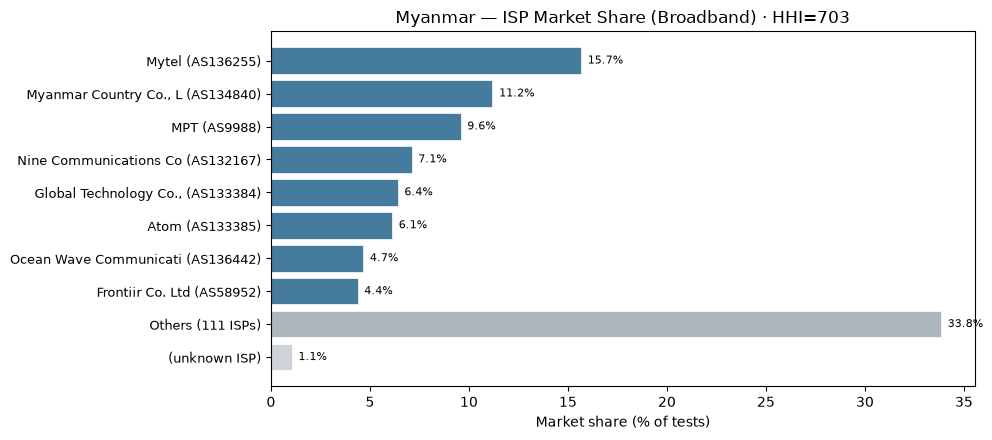

HHI=703 (competitive) | Top5 share=49.9% | unknown=1.1%


In [27]:
_mkt = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เหมือน §17 — HHI อ่อนไหวกับการแตกชื่อมาก
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n
        FROM read_parquet('../../../data/ndt7/mm/mlab_mm_clean.parquet')
        WHERE network_type = 'broadband'
        GROUP BY 1
    )
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n
    FROM g ORDER BY n DESC
""").df()

if _mkt.empty:
    print("No Broadband data — skipping market share.")
else:
    _total = _mkt['n'].sum()
    _mkt['share'] = 100 * _mkt['n'] / _total
    _named = _mkt[_mkt['isp'] != '(unknown)'].reset_index(drop=True)
    _unknown_share = float(_mkt.loc[_mkt['isp'] == '(unknown)', 'share'].sum())
    TOPN = 8
    _top = _named.head(TOPN)
    _others_share = float(_named['share'].iloc[TOPN:].sum())
    # HHI ต้องคิดบนฐานที่มีชื่อเท่านั้น — เดิมหารด้วย _total ที่รวม (unknown) ทำให้ HHI ต่ำกว่าจริง
    _named_share = 100.0 * _named['n'] / _named['n'].sum()
    _hhi = float((_named_share ** 2).sum())

    _rows = list(zip(_top['isp'].str.slice(0, 44), _top['share']))
    if _others_share > 0:
        _rows.append((f"Others ({len(_named) - len(_top)} ISPs)", _others_share))
    if _unknown_share > 0:
        _rows.append(("(unknown ISP)", _unknown_share))
    _labels = [r[0] for r in _rows][::-1]
    _vals = [r[1] for r in _rows][::-1]
    _colors = ['#adb5bd' if l.startswith('Others') else '#ced4da' if l.startswith('(unknown') else '#457b9d' for l in _labels]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(_vals))))
    y = list(range(len(_vals)))
    ax.barh(y, _vals, color=_colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(_labels, fontsize=9)
    for yi, v in zip(y, _vals):
        ax.text(v + max(_vals) * 0.01, yi, f"{v:.1f}%", va='center', fontsize=8)
    ax.set_xlabel('Market share (% of tests)')
    ax.set_title(f"Myanmar — ISP Market Share (Broadband) \u00b7 HHI={_hhi:.0f}")
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/25_market_share.png', dpi=150, bbox_inches='tight')
    plt.show()

    _hhi_note = 'competitive' if _hhi < 1500 else ('moderate' if _hhi < 2500 else 'highly concentrated')
    print(f"HHI={_hhi:.0f} ({_hhi_note}) | Top5 share={_named['share'].head(5).sum():.1f}% | unknown={_unknown_share:.1f}%")


### 19. EDA Key Findings Summary

## Key Findings from EDA — Broadband

- Province-level reliability, regional patterns, GDP/density correlation, UL/DL symmetry,
  and growth trajectory computed the same way as Cambodia/Thailand/Vietnam's tigger notebooks,
  from the DuckDB-tile-binned `is_reliable` export.
- City focus uses Myanmar's own curated population-ranked city list (not a test-volume proxy)
  since that data already existed in the source notebook this was ported from.
- Per-ISP and market-share sections query the raw parquet directly, same as every other tigger
  country's ISP-level sections.
- **This notebook has not been executed in this repo** — treat all of the above as structure,
  not as validated numbers, until run against the full local dataset.


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [28]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_broadband_myanmar_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output instead "
          "for any downstream use that needs raw coverage instead of the reliable subset.)")


Exported 76 rows (reliable-only) -> ../../../data/exports/ndt7_broadband_myanmar_reliable_province_quarterly.csv
   province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable                         region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0      Bago  2023-Q1  2023        1    7.804803    8.304277     235.738708        130.0      1.0         True  Lower Myanmar / Delta-Coastal              2   4867373                 165710.4              124
4  Mandalay  2023-Q1  2023        1   16.592645    9.995477     128.622729        129.0      1.0         True               Central Dry Zone              1   7325965                 165710.4              163
5  Mandalay  2023-Q1  2023        1   16.592645    8.065213     128.622729        129.0      1.0         True               Central Dry Zone              1   7325965                 165710.4              163


---
# Part 2 — Mobile/Cellular

## Full EDA — NDT7 Mobile/Cellular, Myanmar (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [29]:
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_mobile_myanmar_province_quarterly.csv'
GEOJSON  = '../../../data/geo/myanmar_provinces.geojson'
PROV_REF = '../../../data/reference/myanmar_reference.csv'

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

myanmar_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference)")


Master shape: (53, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  9 (of 14 in reference)


In [30]:
# is_reliable already computed upstream (myanmar_ndt7_prep.ipynb, total_tests>=100 only — n_tiles dropped for NDT7, see prep notebook)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")


Reliable province-quarters per label:
label
2023-Q1    3
2023-Q2    3
2023-Q3    4
2023-Q4    4
2024-Q1    2
2024-Q2    2
2024-Q3    3
2024-Q4    3
2025-Q1    4
2025-Q2    3
2025-Q3    3
2025-Q4    3

Overall reliable: 37 / 53 (69.8%)


### 2. Data Quality — Coverage per Province

In [31]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(myanmar_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))


Expected rows (if every province had every quarter): 168 | Actual: 53 | Missing: 115

Provinces with ZERO NDT7 test volume in any quarter (5): ['Chin', 'Kachin', 'Kayah', 'Rakhine', 'Tanitharyi']

Low-test quarters (< 100 tests) — 16 of 53 province-quarter rows
      name   label  total_tests  n_tiles
Ayeyarwady 2023-Q3            4        1
    Magway 2023-Q1            6        1
   Saigang 2023-Q2           10        1
      Shan 2023-Q2           13        1
       Mon 2023-Q4           14        1
   Saigang 2023-Q1           17        1
      Shan 2023-Q1           20        2
   Saigang 2024-Q1           21        1
    Magway 2024-Q1           24        1
      Shan 2023-Q3           33        1
      Bago 2024-Q1           44        2
       Mon 2023-Q3           56        1
      Bago 2024-Q2           60        1
      Bago 2025-Q4           72        1
      Bago 2023-Q4           79        2


In [32]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections below will report "
          "'no reliable data' instead of plotting.")


Filtered to reliable province-quarters: 37 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

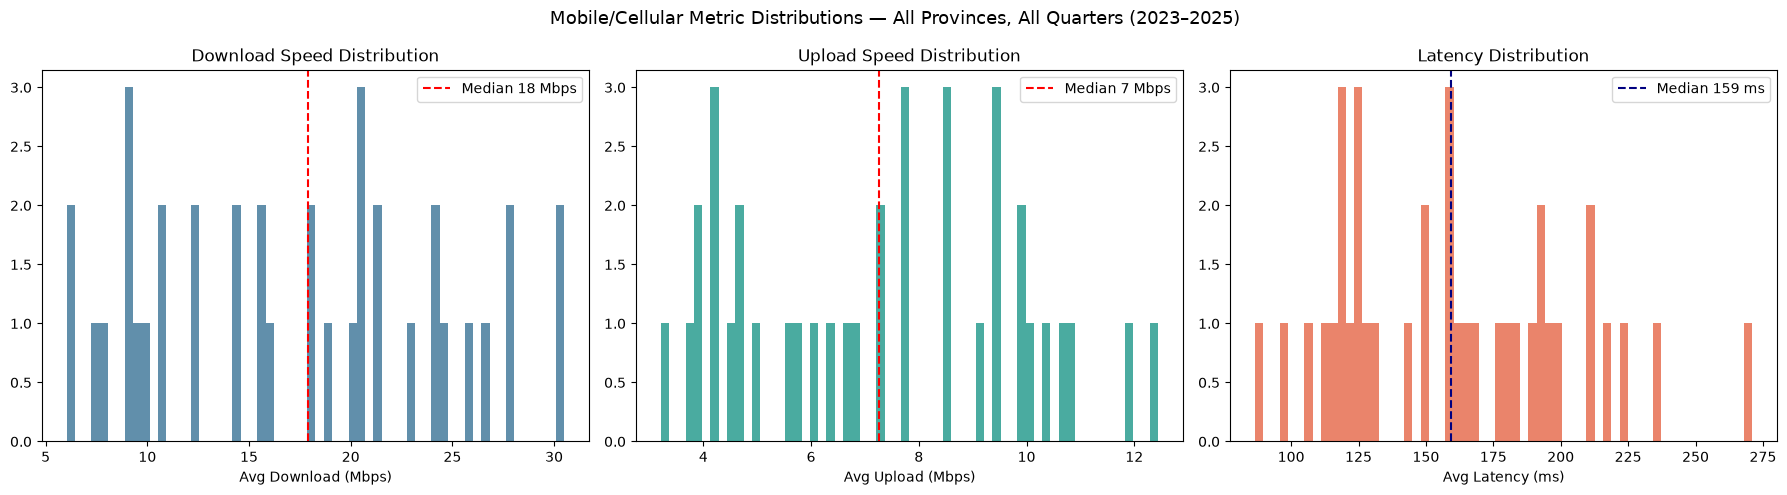

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count       37.00       37.00          37.00        37.00
mean        17.31        7.31         160.13      5121.19
std          7.24        2.58          43.26      8284.09
min          6.03        3.21          86.49       127.00
25%         10.69        4.63         123.81       613.00
50%         17.89        7.26         159.40      1861.00
75%         22.95        9.43         191.19      5399.00
max         30.50       12.44         271.03     32292.00


In [33]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/myanmar/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

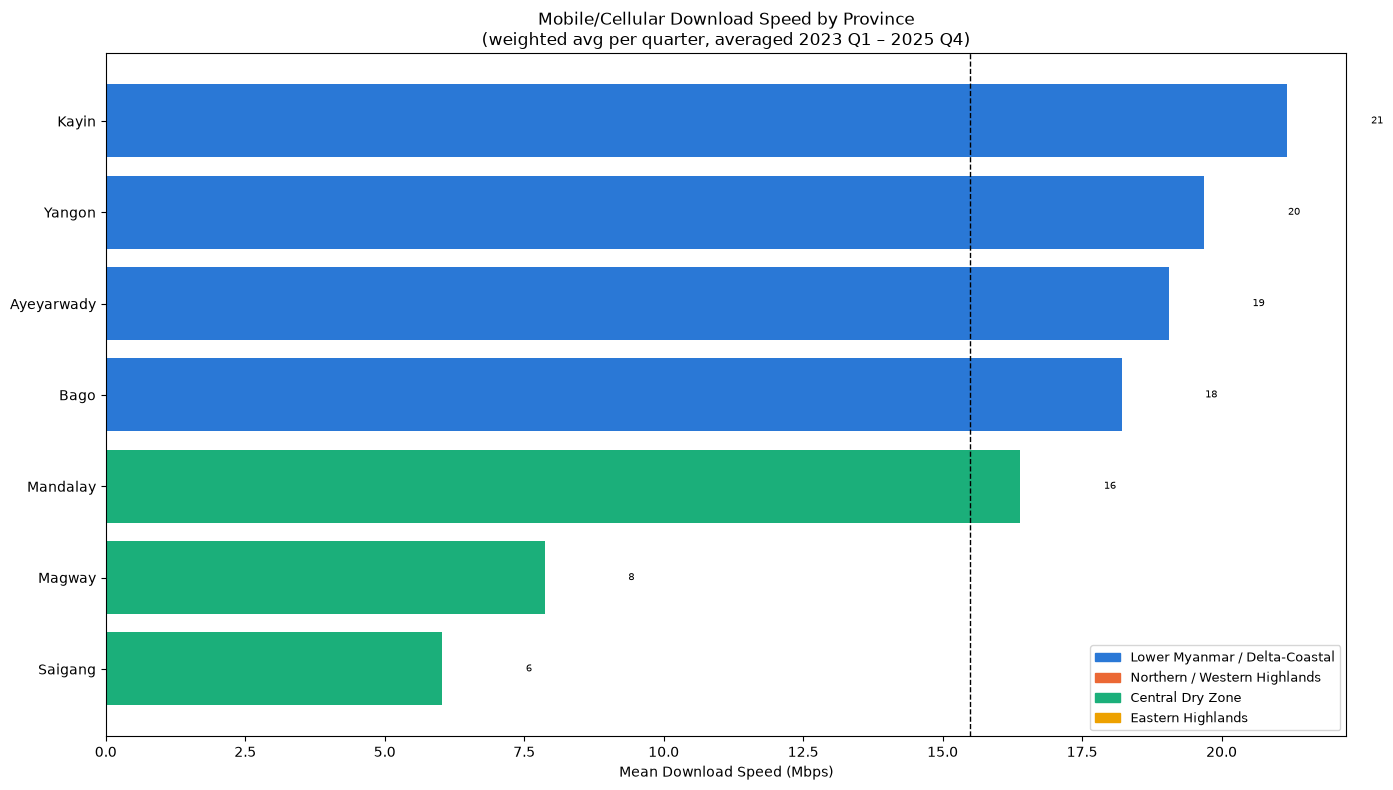

In [34]:
region_colors = {
    'Lower Myanmar / Delta-Coastal': '#2a78d6',
    'Northern / Western Highlands': '#eb6834',
    'Central Dry Zone': '#1baf7a',
    'Eastern Highlands': '#eda100',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Mobile/Cellular — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

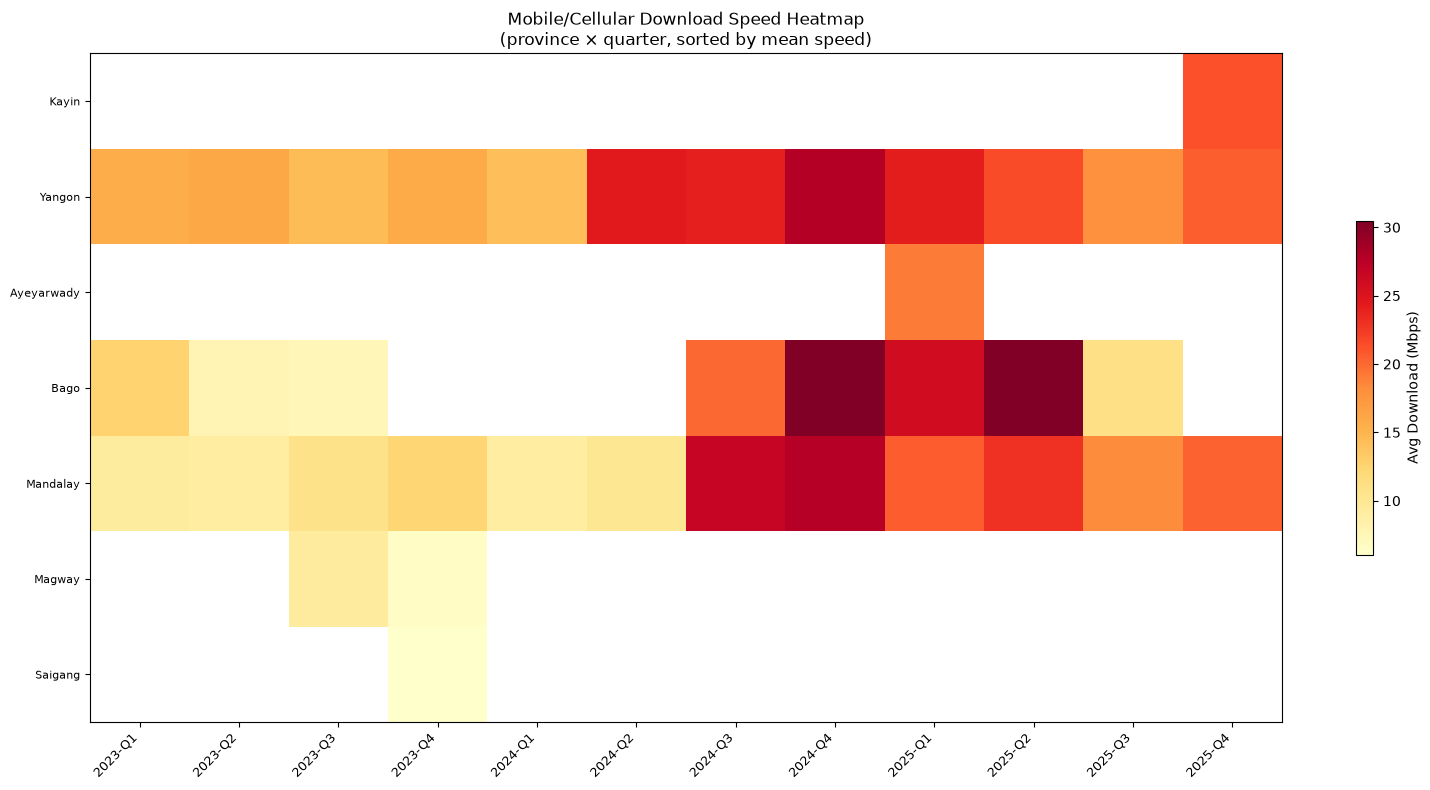

In [35]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()


### 6. Regional Comparison — Download, Upload, Latency

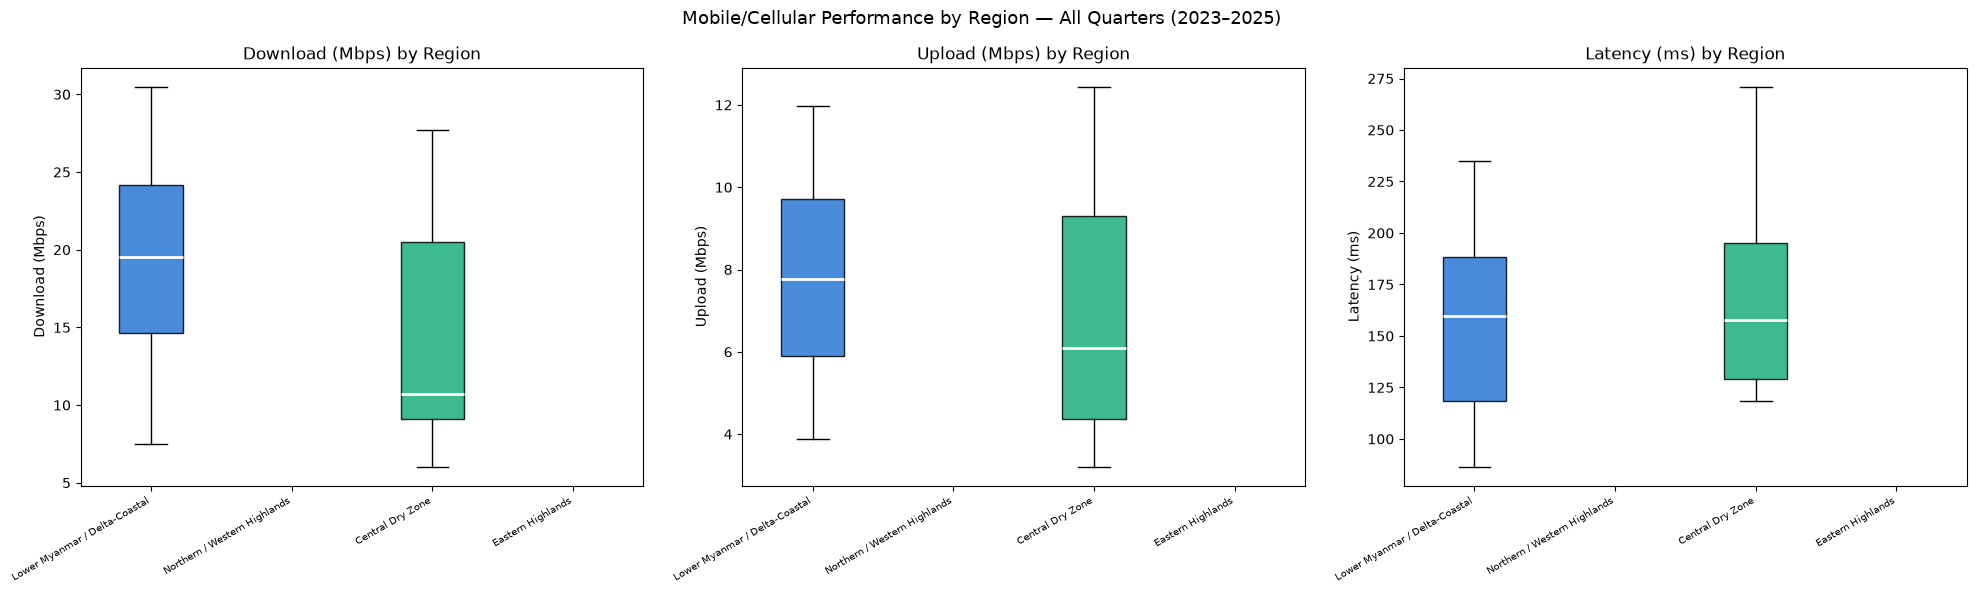

In [36]:
region_order = ['Lower Myanmar / Delta-Coastal', 'Northern / Western Highlands', 'Central Dry Zone', 'Eastern Highlands']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, mlabel, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=7.5)
        ax.set_ylabel(mlabel)
        ax.set_title(f'{mlabel} by Region')
    plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

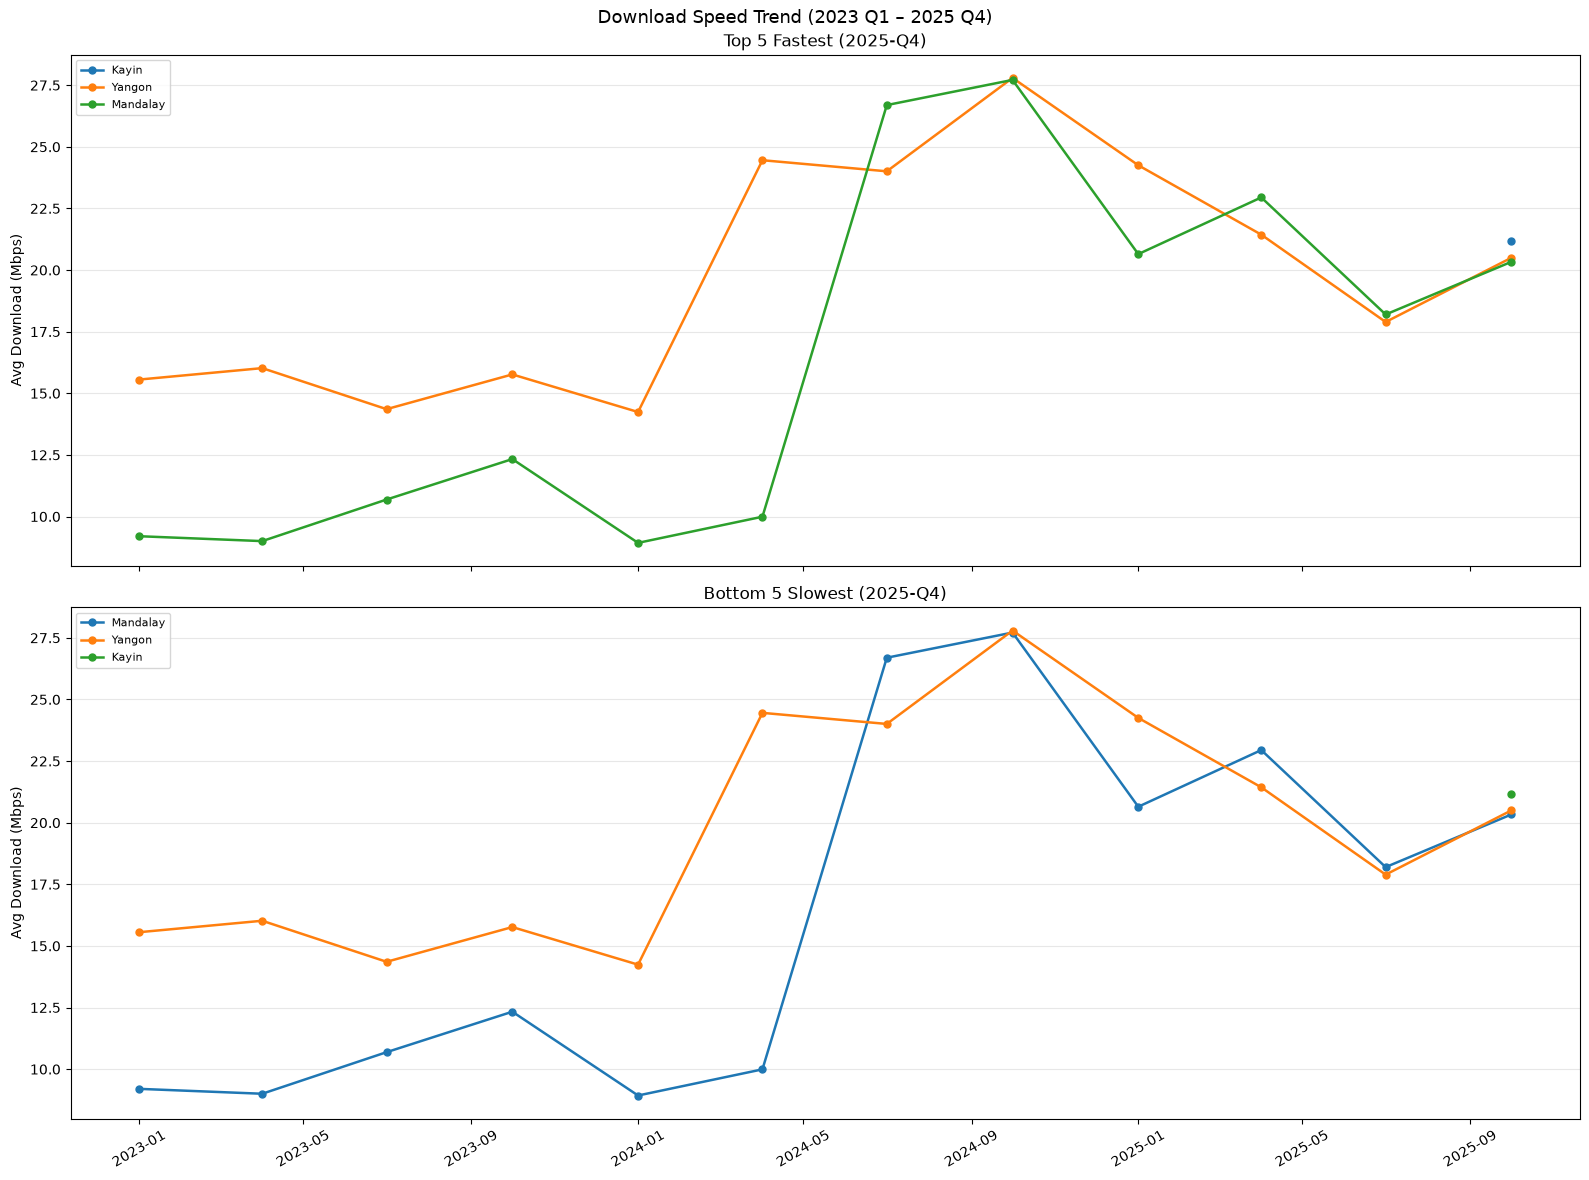

In [37]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

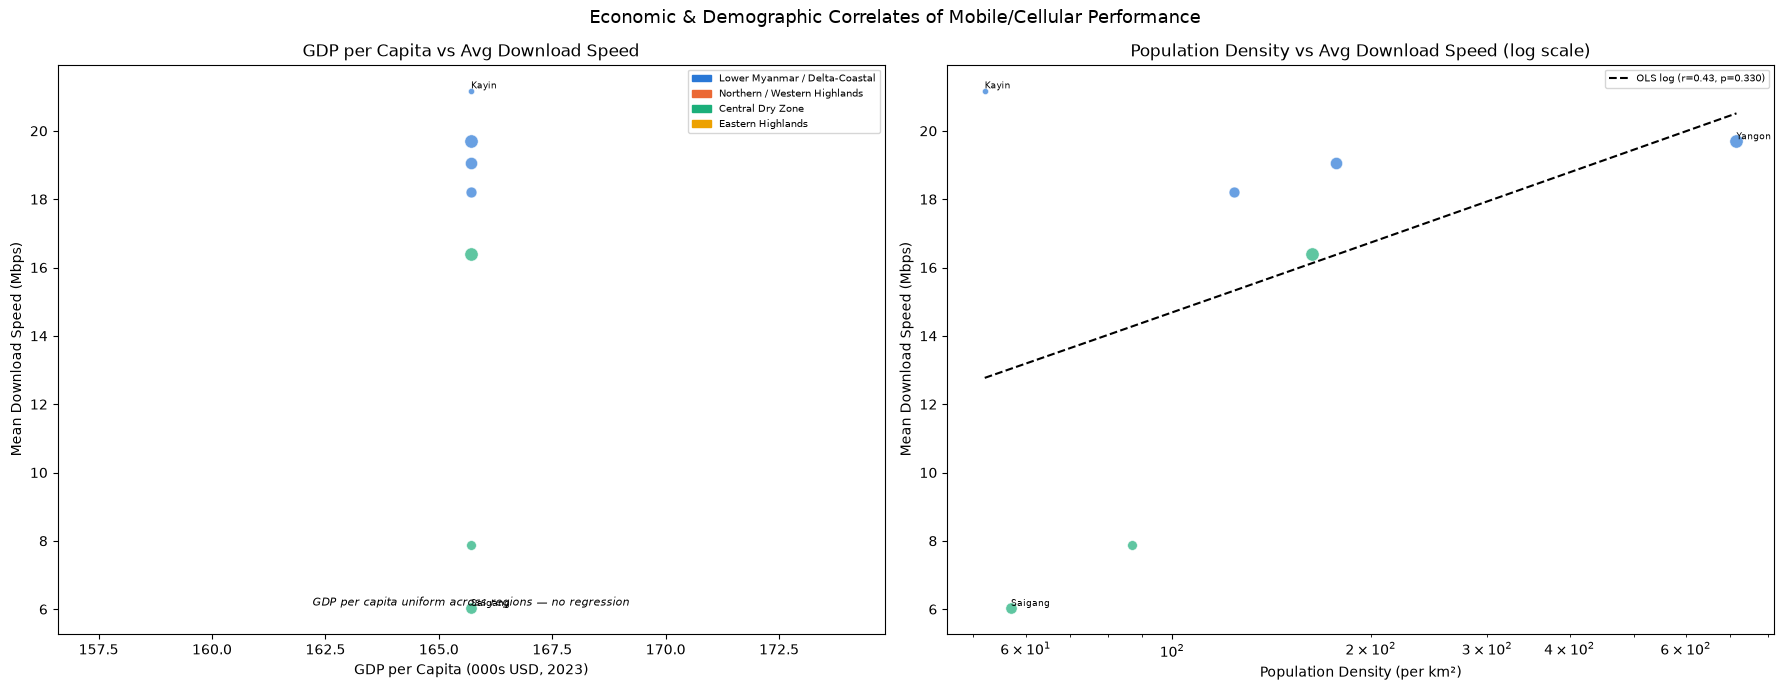

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): 0.435  p=0.3296


In [38]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Mobile/Cellular — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [39]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R² = {mv_model.rsquared:.3f}  (bivariate GDP-only r² = {r**2:.3f})")
        print(f"Adjusted R² = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     2.350
Date:                Thu, 30 Jul 2026   Prob (F-statistic):              0.320
Time:                        13:43:03   Log-Likelihood:                -15.885
No. Observations:                   7   AIC:                             41.77
Df Residuals:                       2   BIC:                             41.50
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### 9. Upload/Download Ratio — Symmetry Check

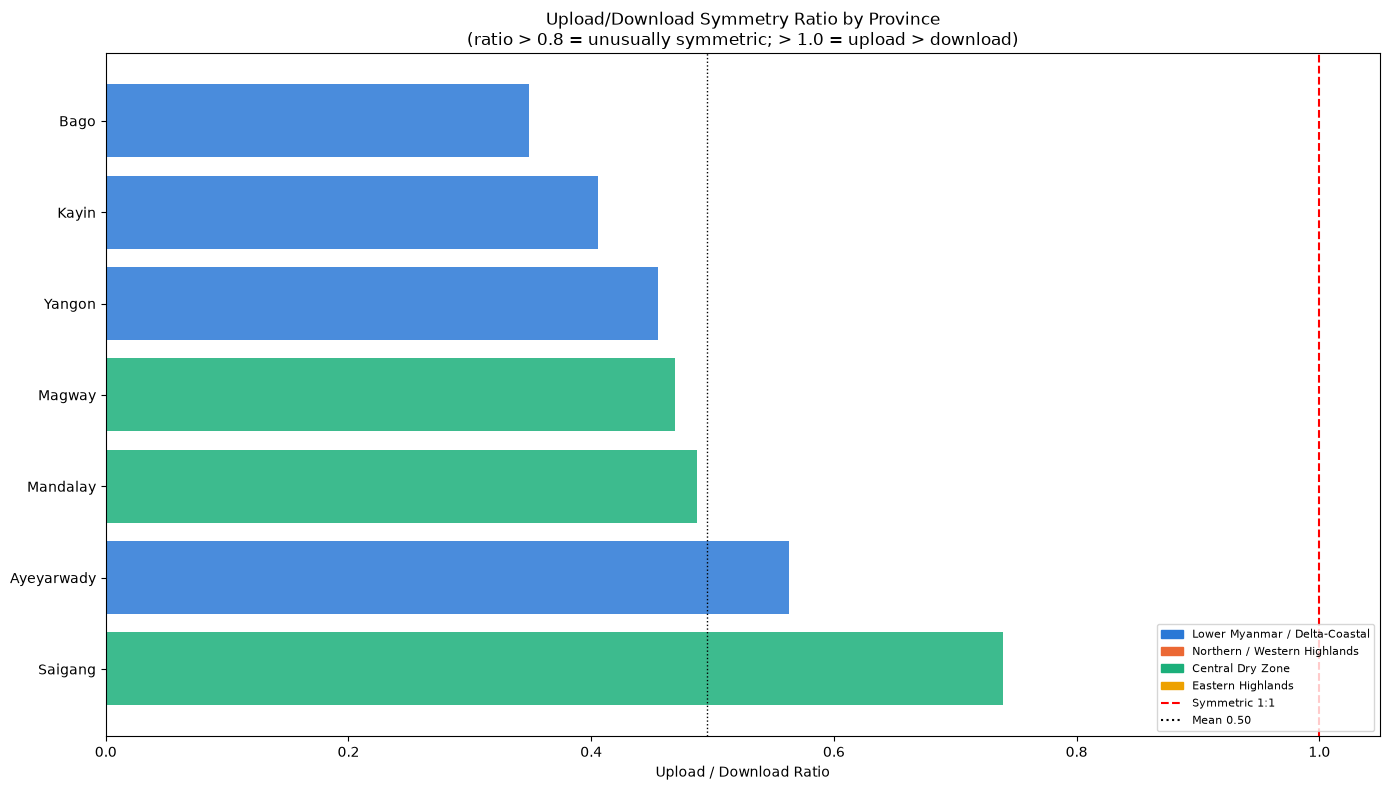

Provinces with UL/DL ratio > 0.8 (0):
Empty DataFrame
Columns: [name, region, ul_dl_ratio]
Index: []


In [40]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
    print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Province Summary — Tier & UL/DL Ratio

In [41]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Mobile/Cellular — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())


### 12. Full Province Summary Table

In [42]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))


      name                        region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
     Kayin Lower Myanmar / Delta-Coastal              3    21.18     8.59    126.89         0.40      627.00                 165710.4
    Yangon Lower Myanmar / Delta-Coastal              1    19.69     8.76    150.75         0.46     9666.17                 165710.4
Ayeyarwady Lower Myanmar / Delta-Coastal              1    19.05    10.73     86.49         0.56     2021.00                 165710.4
      Bago Lower Myanmar / Delta-Coastal              2    18.21     5.34    174.67         0.35      520.50                 165710.4
  Mandalay              Central Dry Zone              1    16.39     7.64    162.89         0.49     5520.25                 165710.4
    Magway              Central Dry Zone              2     7.87     3.51    162.95         0.47      154.00                 165710.4
   Saigang              Central Dry Zone              3     6.

### 13. UL/DL Symmetry — Fiber Penetration Evidence

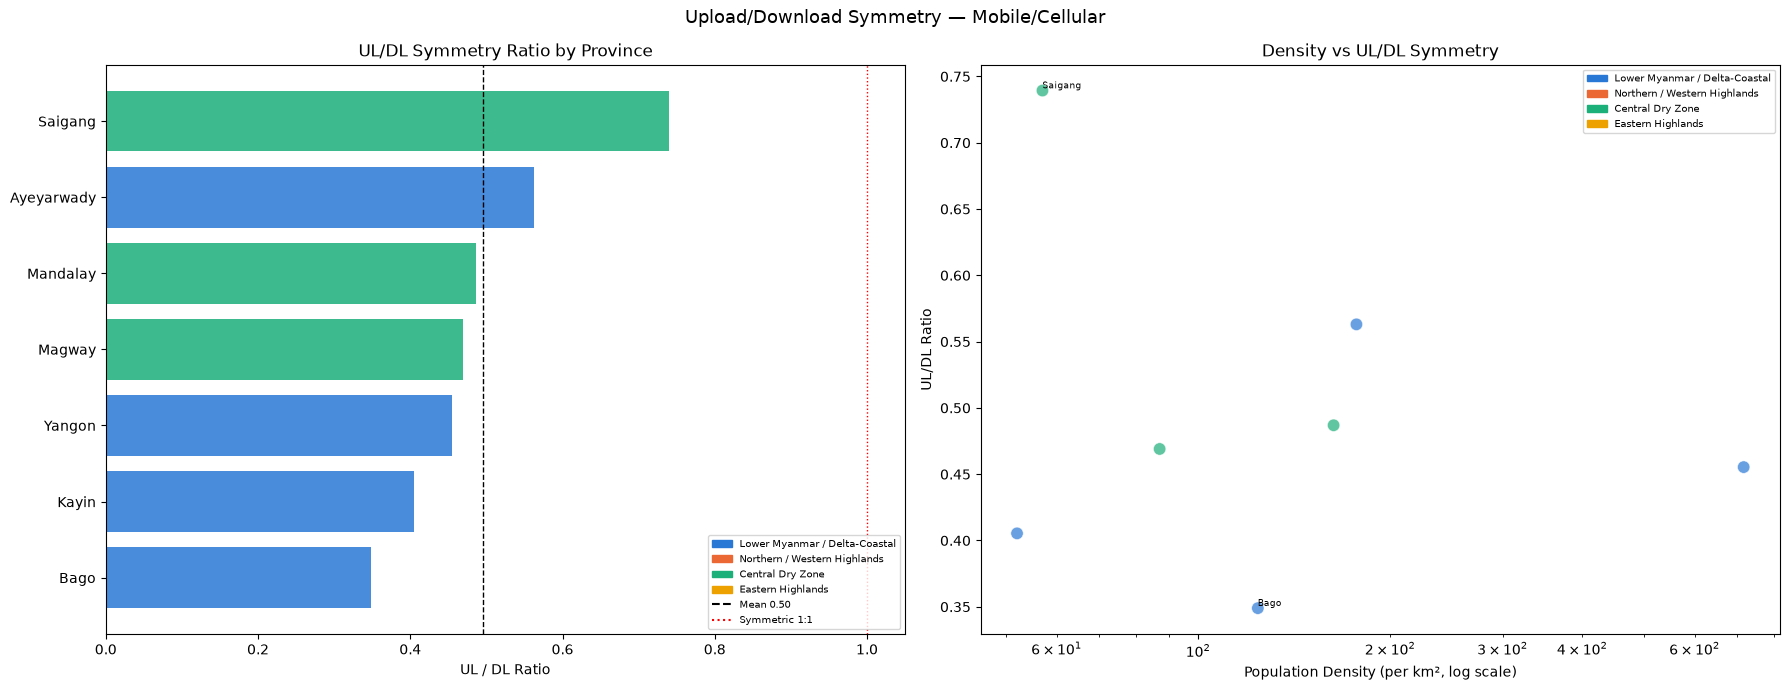

In [43]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Mobile/Cellular', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

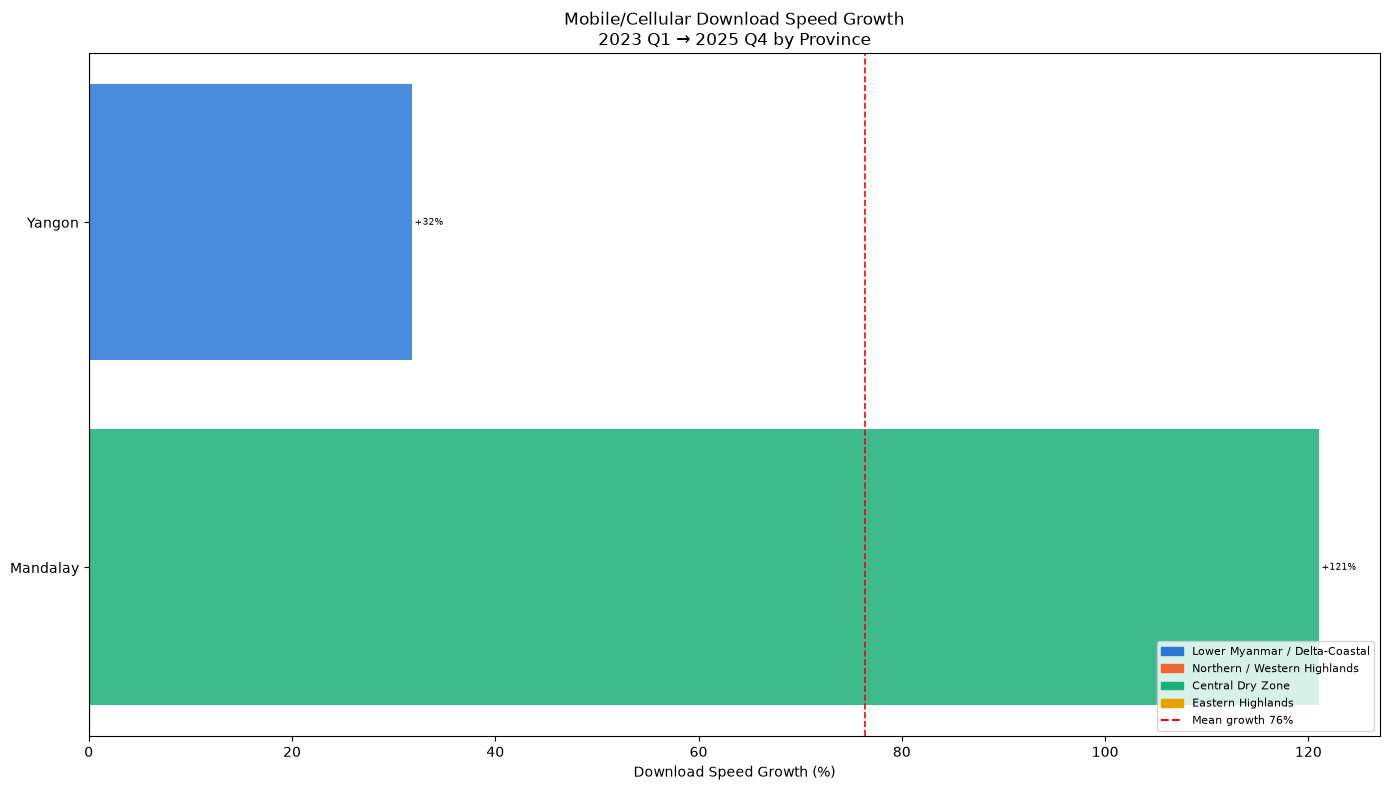

In [44]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 8))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/myanmar/mobile/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()


### 15. Regional Growth Index — Trajectory Shape (Normalized to First Reliable Quarter = 100)
Complements the endpoint-only growth chart above (Q1 → Q4 % change) by showing the full trajectory per region, each region's own first valid quarter rebased to 100. Regions need at least half the available quarters with reliable data to be plotted.

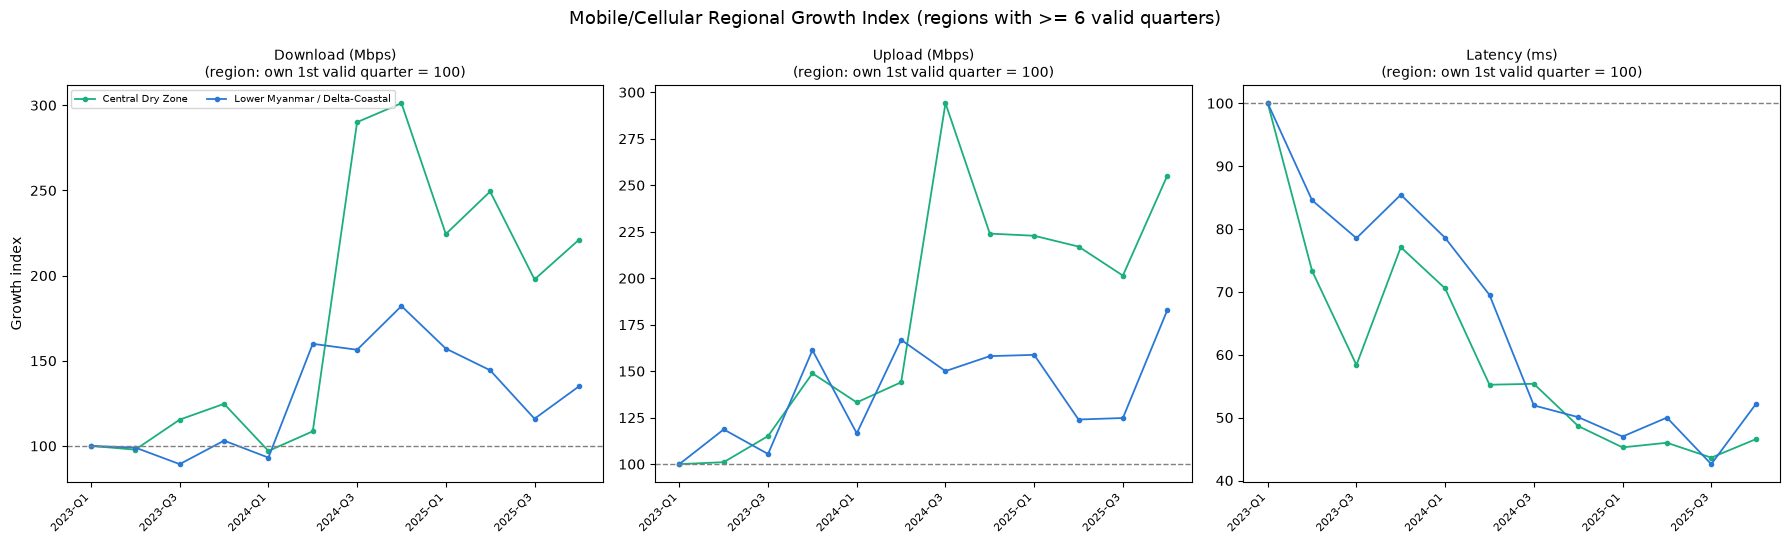

In [45]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional growth-index plot.")
else:
    quarter_order = sorted(master['label'].unique())
    MIN_Q = max(3, len(quarter_order) // 2)

    region_q = (
        master.groupby(['region', 'label'])
        .apply(lambda g: pd.Series({
            'avg_d_mbps': np.average(g['avg_d_mbps'], weights=g['total_tests']),
            'avg_u_mbps': np.average(g['avg_u_mbps'], weights=g['total_tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms_wt'], weights=g['total_tests']),
        }), include_groups=False)
        .reset_index()
    )

    metrics = [('avg_d_mbps', 'Download (Mbps)'), ('avg_u_mbps', 'Upload (Mbps)'), ('avg_lat_ms_wt', 'Latency (ms)')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    any_plotted = False
    for ax, (col, mlabel) in zip(axes, metrics):
        piv = region_q.pivot(index='region', columns='label', values=col).reindex(columns=quarter_order)
        valid = piv.notna().sum(axis=1)
        keep = valid[valid >= MIN_Q].index.tolist()
        if not keep:
            ax.text(0.5, 0.5, 'not enough data', transform=ax.transAxes, ha='center')
            continue
        for reg in keep:
            s = piv.loc[reg].dropna()
            xs = [quarter_order.index(q) for q in s.index]
            ax.plot(xs, s.values / s.iloc[0] * 100, marker='o', ms=3, lw=1.3,
                    color=region_colors.get(reg, 'gray'), label=reg)
            any_plotted = True
        ax.axhline(100, color='grey', ls='--', lw=1)
        step = max(1, len(quarter_order) // 6)
        ax.set_xticks(range(0, len(quarter_order), step))
        ax.set_xticklabels([quarter_order[i] for i in range(0, len(quarter_order), step)], rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{mlabel}\n(region: own 1st valid quarter = 100)', fontsize=10)
    axes[0].set_ylabel('Growth index')
    if any_plotted:
        axes[0].legend(fontsize=7, ncol=2, loc='upper left')
    plt.suptitle(f'Mobile/Cellular Regional Growth Index (regions with >= {MIN_Q} valid quarters)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/21_growth_index_regional.png', dpi=150, bbox_inches='tight')
    plt.show()


### 15.5 Measured Speed Choropleth — Actual NDT7 Download Speed by Province
The "Internet Tier" map earlier in this notebook is a GDP-based expectation. This map is the actual measured NDT7 average, on the same province geometry, so the two can be compared directly.

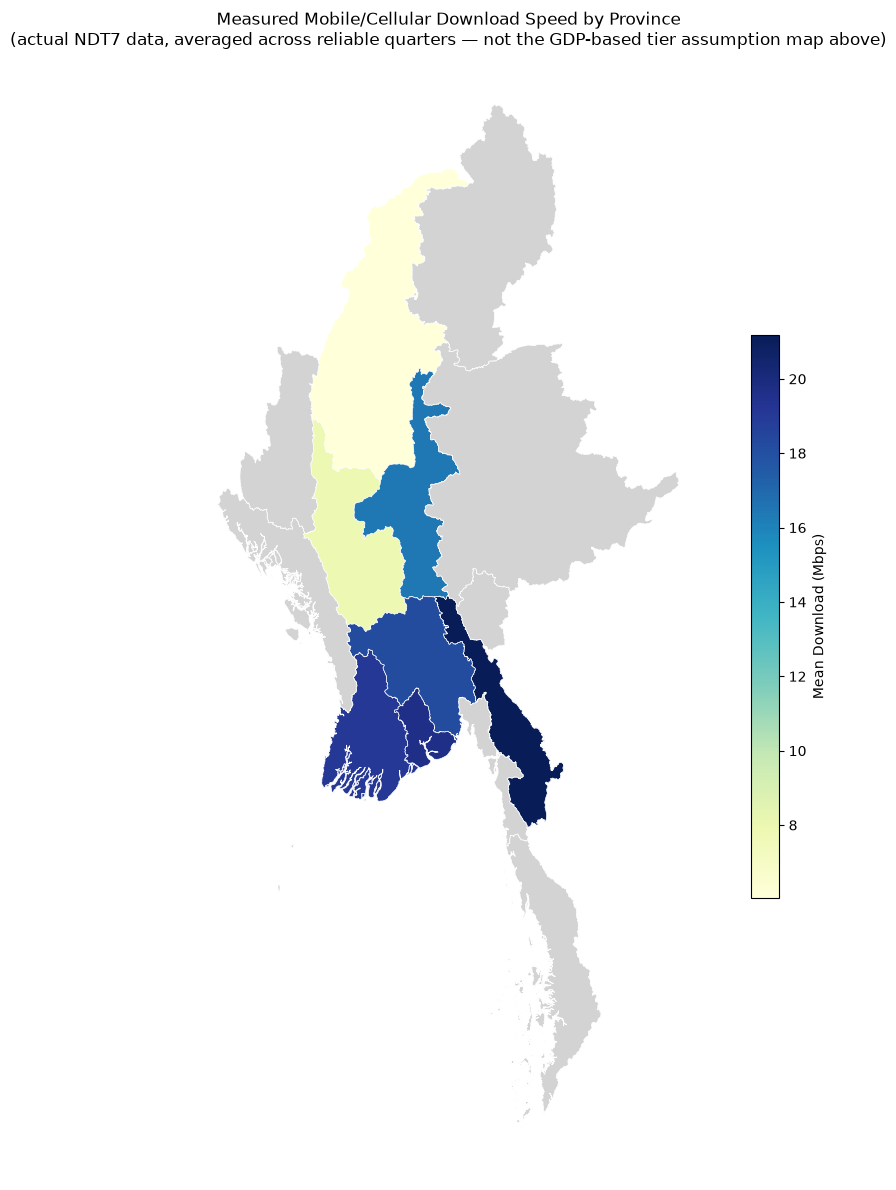

In [46]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping measured-speed choropleth.")
else:
    prov_speed = (
        master.groupby('name')
        .agg(avg_d_mbps=('avg_d_mbps', 'mean'), total_tests=('total_tests', 'sum'))
        .reset_index()
    )
    geo_speed = myanmar_gdf.merge(prov_speed, on='name', how='left')

    fig, ax = plt.subplots(figsize=(10, 12))
    geo_speed.plot(
        column='avg_d_mbps', ax=ax, cmap='YlGnBu', legend=True,
        edgecolor='white', linewidth=0.5,
        legend_kwds={'shrink': 0.5, 'label': 'Mean Download (Mbps)'},
        missing_kwds={'color': 'lightgrey', 'label': 'no reliable data'},
    )
    ax.set_title('Measured Mobile/Cellular Download Speed by Province\n(actual NDT7 data, averaged across reliable quarters — not the GDP-based tier assumption map above)', fontsize=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/22_speed_choropleth.png', dpi=150, bbox_inches='tight')
    plt.show()


### 16. City Focus — Capital + Top Cities by Population (Mobile/Cellular)
★ = capital (**Nay Pyi Taw**) · 5 cities by population (source: Myanmar 2014 census, Dept. of Population)
— kept as a real population-ranked list (ported from the source NDT7 notebook's own curated
`TOP_CITIES`), unlike Cambodia's tigger port which had to fall back to a test-volume proxy for
lack of a population reference file.

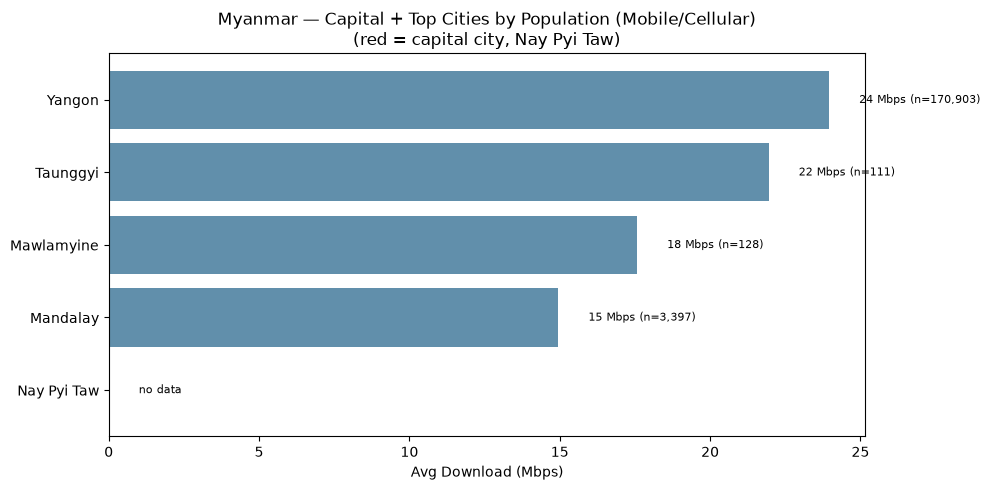

              pop~    n_user  avg_d_mbps  avg_u_mbps  avg_lat_ms
city                                                            
Nay Pyi Taw  1.16M       NaN         NaN         NaN         NaN
Mandalay     1.22M    3397.0        15.0         4.3       206.5
Mawlamyine    491k     128.0        17.6         8.1       126.1
Taunggyi      381k     111.0        21.9         5.3       136.1
Yangon       5.21M  170903.0        24.0         9.4       125.8


In [47]:
import duckdb

TOP_CITIES = [('Yangon', '5.21M'), ('Mandalay', '1.22M'), ('Nay Pyi Taw', '1.16M'), ('Mawlamyine', '491k'), ('Taunggyi', '381k')]
CAPITAL = 'Nay Pyi Taw'
CITY_LIST = [c for c, _ in TOP_CITIES]
POP = dict(TOP_CITIES)

_con = duckdb.connect()
inlist = ",".join("'" + c.replace("'", "''") + "'" for c in CITY_LIST)
_top_cities = _con.execute(f"""
    SELECT city,
           COUNT(*) AS n_user,
           AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps,
           AVG(mean_throughput_mbps) FILTER (WHERE type='upload')   AS avg_u_mbps,
           AVG(CASE WHEN min_rtt < 2000 THEN min_rtt END) AS avg_lat_ms
    FROM read_parquet('../../../data/ndt7/mm/mlab_mm_clean.parquet')
    WHERE network_type = 'cellular' AND city IN ({inlist})
    GROUP BY city
""").df().set_index('city').reindex(CITY_LIST)

if _top_cities['n_user'].isna().all():
    print("No Mobile/Cellular city-level data available for the curated city list — skipping city focus.")
else:
    _top_cities.insert(0, 'pop~', [POP[c] for c in CITY_LIST])
    _top_cities['is_capital'] = [c == CAPITAL for c in CITY_LIST]
    _top_cities = _top_cities.sort_values('avg_d_mbps', ascending=True, na_position='first')
    _colors = ['#e63946' if c else '#457b9d' for c in _top_cities['is_capital']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(_top_cities.index, _top_cities['avg_d_mbps'].fillna(0), color=_colors, alpha=0.85)
    for bar, (_, row) in zip(bars, _top_cities.iterrows()):
        label_txt = f"{row['avg_d_mbps']:.0f} Mbps (n={int(row['n_user']):,})" if pd.notna(row['avg_d_mbps']) else "no data"
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, label_txt, va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Myanmar — Capital + Top Cities by Population (Mobile/Cellular)\n(red = capital city, Nay Pyi Taw)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/23_city_focus.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(_top_cities[['pop~','n_user','avg_d_mbps','avg_u_mbps','avg_lat_ms']].round(1).to_string())


### 17. Per-ISP Ranking — Top ISPs by Test Volume (Mobile/Cellular)
Top 15 ISPs (min 100 tests) ranked by average download speed, bar length shows speed and
label shows test volume.

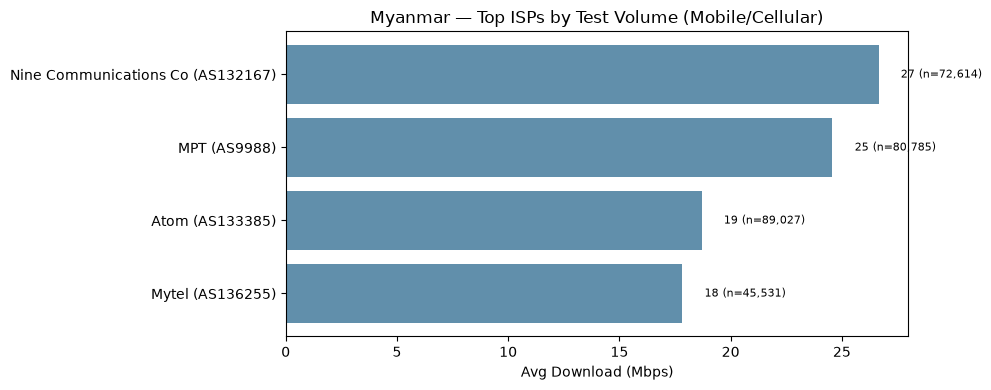

In [48]:
_isp_tbl = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เท่านั้น (HANDOFF ข้อ 1): ip-api คืนชื่อองค์กรลูกค้าสำหรับ leased line
    -- เช่น AS4750 มีชื่อ isp ถึง 420 ชื่อ และชื่อเดียวกันก็กินหลาย ASN (TRUE INTERNET = 9 ASN)
    -- operator/as_name ใช้เป็นป้ายแสดงผลเท่านั้น
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n,
               AVG(mean_throughput_mbps) FILTER (WHERE type='download') AS avg_d_mbps
        FROM read_parquet('../../../data/ndt7/mm/mlab_mm_clean.parquet')
        WHERE network_type = 'cellular'
        GROUP BY 1
    )
    -- ต่อรหัส ASN ท้ายป้าย: 1 แบรนด์มีได้หลาย ASN (ไทย True=2, AIS=3, NT=3, 3BB=2)
    -- ถ้าป้ายซ้ำ แกน categorical ของ matplotlib จะยุบแท่งทับกัน
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown ASN)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n, avg_d_mbps
    FROM g
    WHERE n >= 100
    ORDER BY n DESC
    LIMIT 15
""").df()

if _isp_tbl.empty:
    print("No ISP meets the n>=100 test threshold for Mobile/Cellular — skipping per-ISP ranking.")
else:
    _isp_tbl = _isp_tbl.sort_values('avg_d_mbps', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(_isp_tbl))))
    ax.barh(_isp_tbl['isp'].str.slice(0, 40), _isp_tbl['avg_d_mbps'], color='#457b9d', alpha=0.85)
    for yi, (_, row) in enumerate(_isp_tbl.iterrows()):
        ax.text(row['avg_d_mbps'] + 1, yi, f"{row['avg_d_mbps']:.0f} (n={row['n']:,})", va='center', fontsize=8)
    ax.set_xlabel('Avg Download (Mbps)')
    ax.set_title('Myanmar — Top ISPs by Test Volume (Mobile/Cellular)')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/24_per_isp.png', dpi=150, bbox_inches='tight')
    plt.show()


### 18. Market Share / HHI — ISP Concentration (Mobile/Cellular)
Top 8 ISPs + "Others" + "(unknown ISP)" by share of tests. HHI (Herfindahl-Hirschman Index):
<1500 = competitive, 1500-2500 = moderate concentration, >2500 = highly concentrated.

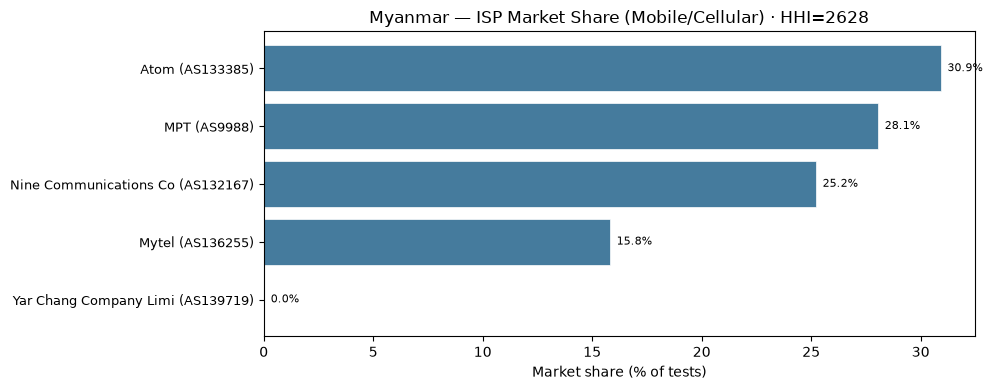

HHI=2628 (highly concentrated) | Top5 share=100.0% | unknown=0.0%


In [49]:
_mkt = _con.execute(f"""
    -- จัดกลุ่มด้วย asn เหมือน §17 — HHI อ่อนไหวกับการแตกชื่อมาก
    WITH g AS (
        SELECT COALESCE(CAST(asn AS VARCHAR), '(unknown)') AS a,
               mode(operator) FILTER (WHERE operator IS NOT NULL) AS op,
               mode(as_name)  FILTER (WHERE as_name  IS NOT NULL) AS an,
               COUNT(*) AS n
        FROM read_parquet('../../../data/ndt7/mm/mlab_mm_clean.parquet')
        WHERE network_type = 'cellular'
        GROUP BY 1
    )
    SELECT CASE WHEN a = '(unknown)' THEN '(unknown)'
                ELSE substr(COALESCE(op, an, 'AS' || a), 1, 22) || ' (AS' || a || ')' END AS isp,
           n
    FROM g ORDER BY n DESC
""").df()

if _mkt.empty:
    print("No Mobile/Cellular data — skipping market share.")
else:
    _total = _mkt['n'].sum()
    _mkt['share'] = 100 * _mkt['n'] / _total
    _named = _mkt[_mkt['isp'] != '(unknown)'].reset_index(drop=True)
    _unknown_share = float(_mkt.loc[_mkt['isp'] == '(unknown)', 'share'].sum())
    TOPN = 8
    _top = _named.head(TOPN)
    _others_share = float(_named['share'].iloc[TOPN:].sum())
    # HHI ต้องคิดบนฐานที่มีชื่อเท่านั้น — เดิมหารด้วย _total ที่รวม (unknown) ทำให้ HHI ต่ำกว่าจริง
    _named_share = 100.0 * _named['n'] / _named['n'].sum()
    _hhi = float((_named_share ** 2).sum())

    _rows = list(zip(_top['isp'].str.slice(0, 44), _top['share']))
    if _others_share > 0:
        _rows.append((f"Others ({len(_named) - len(_top)} ISPs)", _others_share))
    if _unknown_share > 0:
        _rows.append(("(unknown ISP)", _unknown_share))
    _labels = [r[0] for r in _rows][::-1]
    _vals = [r[1] for r in _rows][::-1]
    _colors = ['#adb5bd' if l.startswith('Others') else '#ced4da' if l.startswith('(unknown') else '#457b9d' for l in _labels]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(_vals))))
    y = list(range(len(_vals)))
    ax.barh(y, _vals, color=_colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(_labels, fontsize=9)
    for yi, v in zip(y, _vals):
        ax.text(v + max(_vals) * 0.01, yi, f"{v:.1f}%", va='center', fontsize=8)
    ax.set_xlabel('Market share (% of tests)')
    ax.set_title(f"Myanmar — ISP Market Share (Mobile/Cellular) \u00b7 HHI={_hhi:.0f}")
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/myanmar/mobile/25_market_share.png', dpi=150, bbox_inches='tight')
    plt.show()

    _hhi_note = 'competitive' if _hhi < 1500 else ('moderate' if _hhi < 2500 else 'highly concentrated')
    print(f"HHI={_hhi:.0f} ({_hhi_note}) | Top5 share={_named['share'].head(5).sum():.1f}% | unknown={_unknown_share:.1f}%")


### 19. EDA Key Findings Summary

## Key Findings from EDA — Mobile/Cellular

- Province-level reliability, regional patterns, GDP/density correlation, UL/DL symmetry,
  and growth trajectory computed the same way as Cambodia/Thailand/Vietnam's tigger notebooks,
  from the DuckDB-tile-binned `is_reliable` export.
- City focus uses Myanmar's own curated population-ranked city list (not a test-volume proxy)
  since that data already existed in the source notebook this was ported from.
- Per-ISP and market-share sections query the raw parquet directly, same as every other tigger
  country's ISP-level sections.
- **This notebook has not been executed in this repo** — treat all of the above as structure,
  not as validated numbers, until run against the full local dataset.


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [50]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_mobile_myanmar_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output instead "
          "for any downstream use that needs raw coverage instead of the reliable subset.)")


Exported 37 rows (reliable-only) -> ../../../data/exports/ndt7_mobile_myanmar_reliable_province_quarterly.csv
   province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable                         region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0      Bago  2023-Q1  2023        1   12.548829    4.633701     182.064087          160        2         True  Lower Myanmar / Delta-Coastal              2   4867373                 165710.4              124
2  Mandalay  2023-Q1  2023        1    9.201606    4.231068     271.032202          804        4         True               Central Dry Zone              1   7325965                 165710.4              163
5    Yangon  2023-Q1  2023        1   15.557546    6.342268     235.041598         1632        4         True  Lower Myanmar / Delta-Coastal              1   7360703                 165710.4              716
